<a href="https://colab.research.google.com/github/aprie06/wbp-pipeline-analysis/blob/main/WBP_Pipeline_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workforce Bridge Program — Intern Pipeline Analysis
## Predicting Attrition and Identifying High-Quality Employer Partners

**Dataset:** Workforce Bridge Program (WBP) — anonymized per FERPA  
**Scope:** 1,193 intern placements across 5 campuses, FY2020–FY2024  
**Tools:** Python · pandas · matplotlib · seaborn · scikit-learn

---

### Project Overview

This notebook presents an end-to-end people analytics investigation of
four and a half years of internship placement data from a multi-campus
workforce development program at a public community college district.

The analysis is organized into three connected parts:

- **Part 1 — Pipeline Funnel Analysis:** Where do students exit the program, and when?
- **Part 2 — Employer Quality Analysis:** Which employer partners drive the best outcomes?
- **Part 3 — Policy Recommendations:** What operational changes does the data support?

> **Data privacy:** All student identifiers have been anonymized per FERPA.
> Student names, institutional IDs, and contact information are replaced
> with coded equivalents. Employer names are retained as organizational
> entities. Campus names are replaced with Campus A through Campus E.
> The institution is not identified.


---
## 0. Environment Setup

In [1]:
# Uncomment if running in Colab and openpyxl is not installed
# !pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#E0E0E0',
    'grid.linewidth':   0.7,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

PALETTE = {
    'Planned Completion': '#2ECC71',
    'Re-engagement':      '#3498DB',
    'Student Exit':       '#E74C3C',
    'Employer Exit':      '#E67E22',
    'Administrative Exit':'#95A5A6',
}

print("Environment ready.")


Environment ready.


### 0.1 Load the Anonymized Dataset

Upload `WBP_Anonymized.xlsx` to Colab using the file panel on the left,
then run this cell.


In [10]:
FILE = '/content/drive/MyDrive/workforce_bridge/WBP_Anonymized.xlsx'

xl = pd.ExcelFile(FILE)
print("Sheets found:", xl.sheet_names)

placements  = pd.read_excel(FILE, sheet_name='Total Placements')
daily_hired = pd.read_excel(FILE, sheet_name='Daily Hired Report')
ended_curr  = pd.read_excel(FILE, sheet_name='Ended Assignments')
ended_arch  = pd.read_excel(FILE, sheet_name='ARCHIVED-Ended Assignments')
on_assign   = pd.read_excel(FILE, sheet_name='Data Currently on Assignment')
ncns        = pd.read_excel(FILE, sheet_name='PLACED-No Call and No Shows')

print(f"\nRecord counts:")
print(f"  Total Placements:           {len(placements):>5}")
print(f"  Daily Hired Report:         {len(daily_hired):>5}")
print(f"  Ended Assignments:          {len(ended_curr):>5}")
print(f"  ARCHIVED-Ended Assignments: {len(ended_arch):>5}")
print(f"  Currently on Assignment:    {len(on_assign):>5}")
print(f"  No Call No Shows:           {len(ncns):>5}")

Sheets found: ['Total Placements', 'Daily Hired Report', 'Ended Assignments', 'ARCHIVED-Ended Assignments', 'Data Currently on Assignment', 'PLACED-No Call and No Shows']

Record counts:
  Total Placements:            1193
  Daily Hired Report:          1193
  Ended Assignments:            649
  ARCHIVED-Ended Assignments:   544
  Currently on Assignment:       56
  No Call No Shows:              52


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# Preview column names — used to build the rename mapping below
print("=== Total Placements columns ===")
print(list(placements.columns))
print("\n=== Ended Assignments columns ===")
print(list(ended_curr.columns))


=== Total Placements columns ===
['Student ID', 'Student Name', 'ACES ID', 'Banner ID', 'College', 'Employer', 'Major', 'Start Date', 'End Date', 'Status', 'Reason', 'Semester', 'Academic Year', 'Hours Per Week']

=== Ended Assignments columns ===
['Student ID', 'Student Name', 'ACES ID', 'College', 'Employer', 'Start Date', 'End Date', 'Reason', 'Semester', 'Academic Year']


---
## Part 1 — Data Cleaning & Outcome Classification

### 1.1 Standardize Column Names

Edit the mapping dictionaries below to match your actual column names
as printed by the cell above.


In [12]:
# ── Column rename mapping ────────────────────────────────────────────────────
# Left  = what the Excel file actually has
# Right = what we use throughout this notebook

PLACEMENT_COLS = {
    'Student ID':     'student_id',
    'Student Name':   'student_name',
    'ACES ID':        'student_code',
    'Banner ID':      'system_id',
    'College':        'campus',
    'Employer':       'employer',
    'Start Date':     'start_date',
    'End Date':       'end_date',
    'Status':         'status',
    'Reason':         'reason_code',
    'Semester':       'semester',
    'Academic Year':  'academic_year',
    'Major':          'major',
    'Hours Per Week': 'hours_per_week',
}

ENDED_COLS = {
    'Student ID':     'student_id',
    'Student Name':   'student_name',
    'ACES ID':        'student_code',
    'College':        'campus',
    'Employer':       'employer',
    'Start Date':     'start_date',
    'End Date':       'end_date',
    'Reason':         'reason_code',
    'Semester':       'semester',
    'Academic Year':  'academic_year',
}

def safe_rename(df, mapping):
    existing = {k: v for k, v in mapping.items() if k in df.columns}
    return df.rename(columns=existing)

placements = safe_rename(placements, PLACEMENT_COLS)
ended_curr = safe_rename(ended_curr, ENDED_COLS)
ended_arch = safe_rename(ended_arch, ENDED_COLS)

print("Renaming complete.")
print("Placements columns:", list(placements.columns))


Renaming complete.
Placements columns: ['student_id', 'student_name', 'student_code', 'system_id', 'campus', 'employer', 'major', 'start_date', 'end_date', 'status', 'reason_code', 'semester', 'academic_year', 'hours_per_week']


### 1.2 Outcome Classification Framework

The five categories below reflect how program outcomes were understood
operationally. The raw reason codes carry institutional meaning that is
not visible from the codes alone.

| Category | Meaning |
|---|---|
| **Planned Completion** | Student finished as intended — term ended, graduated, or was hired |
| **Re-engagement** | Student left to return for another placement — a positive signal |
| **Student Exit** | Student-driven early departure |
| **Employer Exit** | Employer-driven early departure |
| **Administrative Exit** | Program-level action unrelated to student or employer performance |

> **Note on structured placements:** Some employer partners run fixed-length
> programs (for example, a structured 9-week placement). Their
> `Internship Term Ended` records reflect planned completion, not dropout.
> These records are flagged with `is_structured_program = True` and
> excluded from attrition timing calculations to avoid distorting the
> distribution.


In [46]:
# ── Outcome classifier ───────────────────────────────────────────────────────

# Employers with structured fixed-length programs
# Add any others you know belong in this category
STRUCTURED_EMPLOYER_KEYWORDS = [
    'Accenture',         # 9-week structured placement
    'MIMS Institute',    # structured short-term
]

def classify_outcome(row):
    reason  = str(row.get('reason_code', '')).strip().lower()
    planned = [
        'internship term ended', 'term ended', 'graduate',
        'hired by employer', 'hired permanently',
        'hired by non-wbp employer permanently',
    ]
    reengage = [
        'seeking new wbp assignment', 'seeking new assignment',
        'seeking new aotj assignment',   # legacy code in dataset
    ]
    student_exit = [
        'voluntary withdrawal', 'student ended assignment',
        'no call no show', 'did not complete employer pre-screen',
        'student withdrew', 'abandoned',
    ]
    employer_exit = [
        'employer ended assignment', 'employer terminated',
    ]
    admin_exit = [
        'ineligible-not enrolled', 'wbp pause', 'aotj pause',
        'administrative hold', 'program ended',
    ]
    for c in planned:
        if c in reason: return 'Planned Completion'
    for c in reengage:
        if c in reason: return 'Re-engagement'
    for c in student_exit:
        if c in reason: return 'Student Exit'
    for c in employer_exit:
        if c in reason: return 'Employer Exit'
    for c in admin_exit:
        if c in reason: return 'Administrative Exit'
    return 'Unclassified'

def flag_structured(row):
    emp = str(row.get('employer', '')).strip()
    return any(kw.lower() in emp.lower() for kw in STRUCTURED_EMPLOYER_KEYWORDS)

ended_curr['outcome'] = ended_curr.apply(classify_outcome, axis=1)
ended_arch['outcome'] = ended_arch.apply(classify_outcome, axis=1)
ended_curr['is_structured_program'] = ended_curr.apply(flag_structured, axis=1)
ended_arch['is_structured_program'] = ended_arch.apply(flag_structured, axis=1)

# Define the renaming map for employers
employer_rename_map = {
    'Bexar County': 'County Services',
    'Texas A&M San Antonio': 'University Partner'
}
# Apply renaming to the 'employer' column of ended_curr and ended_arch
ended_curr['employer'] = ended_curr['employer'].replace(employer_rename_map)
ended_arch['employer'] = ended_arch['employer'].replace(employer_rename_map)

ended_all = pd.concat([ended_curr, ended_arch], ignore_index=True)

unclassified = (ended_all['outcome'] == 'Unclassified').sum()
total_ended  = len(ended_all)
print(f"Total ended assignments:  {total_ended}")
print(f"Classified:               {total_ended - unclassified}  ({(1 - unclassified/total_ended)*100:.1f}%)")
print(f"Unclassified:             {unclassified}")

if unclassified > 0:
    print("\nUnclassified reason codes (add these to the classifier above):")
    print(ended_all[ended_all['outcome'] == 'Unclassified']['reason_code'].value_counts())

Total ended assignments:  1193
Classified:               1193  (100.0%)
Unclassified:             0


In [14]:
# ── Date parsing and tenure calculation ──────────────────────────────────────
for df in [ended_all, placements]:
    for col in ['start_date', 'end_date']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

ended_all['tenure_days'] = (
    ended_all['end_date'] - ended_all['start_date']
).dt.days

neg  = (ended_all['tenure_days'] < 0).sum()
null = ended_all['tenure_days'].isna().sum()
print(f"Tenure calculated: {total_ended - null} records")
print(f"Negative tenure (data quality flag): {neg}")
print(f"Missing tenure:                      {null}")
print(f"\nMedian tenure: {ended_all['tenure_days'].median():.0f} days")
print(f"Mean tenure:   {ended_all['tenure_days'].mean():.0f} days")


Tenure calculated: 1193 records
Negative tenure (data quality flag): 0
Missing tenure:                      0

Median tenure: 80 days
Mean tenure:   90 days


In [15]:
# ── Final distribution check ─────────────────────────────────────────────────
print("=== Outcome Distribution ===")
outcome_counts = ended_all['outcome'].value_counts()
for outcome, count in outcome_counts.items():
    pct = count / len(ended_all) * 100
    print(f"  {outcome:<25} {count:>4}  ({pct:.1f}%)")

print(f"\n=== Structured Program Records ===")
print(ended_all['is_structured_program'].value_counts().to_string())

if 'campus' in ended_all.columns:
    print(f"\n=== Campus Distribution ===")
    print(ended_all['campus'].value_counts().to_string())


=== Outcome Distribution ===
  Planned Completion         770  (64.5%)
  Student Exit               195  (16.3%)
  Re-engagement              103  (8.6%)
  Employer Exit               75  (6.3%)
  Administrative Exit         50  (4.2%)

=== Structured Program Records ===
is_structured_program
False    915
True     278

=== Campus Distribution ===
campus
Campus B    262
Campus A    245
Campus D    242
Campus E    227
Campus C    217


### 1.4 Anonymize Employer Names by Internship Duration

To protect privacy while retaining insights into employer performance, we will anonymize employer names. Employers will be grouped into categories based on the average tenure (duration) of internships they offer. This allows for analysis of employer groups based on internship duration without revealing specific employer identities.

In [50]:
# Ensure 'start_date' and 'end_date' are datetime objects and calculate 'tenure_days'
# This block is moved from cell 71ace51b to ensure tenure_days is present
# before it's used in this cell.
for col in ['start_date', 'end_date']:
    if col in ended_all.columns:
        ended_all[col] = pd.to_datetime(ended_all[col], errors='coerce')

ended_all['tenure_days'] = (
    ended_all['end_date'] - ended_all['start_date']
).dt.days

# Calculate the average tenure days for each employer
avg_tenure_by_employer = ended_all.groupby('employer')['tenure_days'].mean()

# Create categories (quantiles) based on average tenure days
# Using 4 categories: 'Group A' (shortest tenure) to 'Group D' (longest tenure)
num_groups = 4
labels = [f'Employer Group {chr(65 + i)}' for i in range(num_groups)]

employer_tenure_groups = pd.qcut(
    avg_tenure_by_employer,
    q=num_groups,
    labels=labels,
    duplicates='drop' # Handle cases where there are fewer unique quantiles than q
)

# Create a mapping from original employer name to the new anonymized group
employer_anonymization_map = employer_tenure_groups.to_dict()

# Apply the anonymization map to the 'employer' column in ended_all
ended_all['anonymized_employer'] = ended_all['employer'].map(employer_anonymization_map)

# Remove the original 'employer' column
ended_all = ended_all.drop(columns=['employer'])

print("Employer names anonymized based on average internship tenure.")
print("Here's a sample of the updated DataFrame with 'anonymized_employer' instead of 'employer':")
display(ended_all.head())

Employer names anonymized based on average internship tenure.
Here's a sample of the updated DataFrame with 'anonymized_employer' instead of 'employer':


,student_id,student_name,student_code,campus,start_date,end_date,reason_code,semester,academic_year,outcome,is_structured_program,tenure_days,anonymized_employer
0,STU0004,Student_STU0004,WBP55082,Campus C,2022-09-11,2023-01-29,Seeking New WBP Assignment,Fall,2022-2023,Re-engagement,False,140,Employer Group C
1,STU0005,Student_STU0005,WBP85674,Campus A,2024-06-07,2024-08-11,Hired by Employer,Summer,2023-2024,Planned Completion,True,65,Employer Group A
2,STU0006,Student_STU0006,WBP31319,Campus C,2024-04-01,2024-08-22,Graduate,Spring,2023-2024,Planned Completion,False,143,Employer Group D
3,STU0007,Student_STU0007,WBP31417,Campus D,2022-09-08,2022-11-26,Hired by Employer,Fall,2022-2023,Planned Completion,False,79,Employer Group D
4,STU0008,Student_STU0008,WBP62581,Campus A,2023-11-03,2024-04-08,Hired by Non-WBP Employer Permanently,Fall,2023-2024,Planned Completion,False,157,Employer Group D


### Distribution of Student Exit Rates Across Employers

To understand the spread of 'Student Exit' rates among employer partners, we visualize their distribution using a histogram. This helps to identify common ranges and any significant outliers.

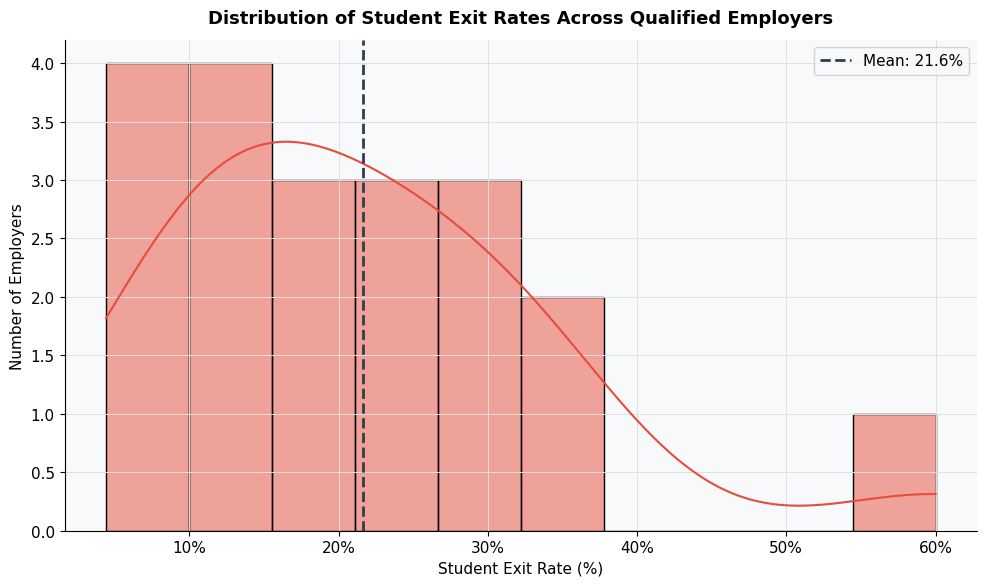

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure exit_rates is a Series from emp_qualified for accurate distribution
# (re-calculating to ensure it's up-to-date and directly from emp_qualified)
exit_rates = emp_qualified.get('Student Exit', pd.Series(dtype=float)).dropna()

if not exit_rates.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(exit_rates, bins=10, kde=True, color='#E74C3C', ax=ax)
    ax.set_title('Distribution of Student Exit Rates Across Qualified Employers', pad=12)
    ax.set_xlabel('Student Exit Rate (%)')
    ax.set_ylabel('Number of Employers')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100)) # Format x-axis as percentages

    # Add a vertical line for the mean exit rate
    mean_exit = exit_rates.mean()
    ax.axvline(mean_exit, color='#2C3E50', linestyle='--', linewidth=2, label=f'Mean: {mean_exit:.1f}%')
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No 'Student Exit' rates available to plot distribution.")

In [53]:
MIN_PLACEMENTS = 5

anonymized_employer_outcomes = (
    ended_all.groupby(['anonymized_employer', 'outcome'])
    .size().unstack(fill_value=0)
    .reindex(columns=outcome_order, fill_value=0)
)
anonymized_employer_totals = anonymized_employer_outcomes.sum(axis=1)
anonymized_employer_pct    = anonymized_employer_outcomes.div(anonymized_employer_totals, axis=0) * 100

emp_qualified_anon = anonymized_employer_pct[anonymized_employer_totals >= MIN_PLACEMENTS].copy()

# Get Student Exit rates for the qualified anonymized employer groups
anon_exit_rates = emp_qualified_anon.get('Student Exit', pd.Series(dtype=float)).dropna()

if not anon_exit_rates.empty:
    # Sort in descending order to get the highest exit rates
    highest_exit_rate_anon_employers = anon_exit_rates.sort_values(ascending=False)

    print("Anonymized Employer Groups with Highest Student Exit Rates:")
    display(highest_exit_rate_anon_employers.head())
else:
    print("No 'Student Exit' rates available for anonymized employer groups.")

Anonymized Employer Groups with Highest Student Exit Rates:


,Student Exit
anonymized_employer,
Employer Group B,28.491620
Employer Group C,17.786561
Employer Group A,14.794521
Employer Group D,11.363636


In [54]:
print("Comparison of Anonymized Employer Group Characteristics:")

# Combine percentage outcomes and total placements for a comprehensive view
comparison_df = anonymized_employer_pct.copy()
comparison_df['total_placements'] = anonymized_employer_totals

# Order columns for better readability
display_columns = ['Planned Completion', 'Re-engagement', 'Student Exit', 'Employer Exit', 'Administrative Exit', 'total_placements']
comparison_df = comparison_df[display_columns]

# Sort by 'Student Exit' for easy comparison based on the previous request
comparison_df_sorted = comparison_df.sort_values(by='Student Exit', ascending=False)

display(comparison_df_sorted.round(2))

Comparison of Anonymized Employer Group Characteristics:


outcome,Planned Completion,Re-engagement,Student Exit,Employer Exit,Administrative Exit,total_placements
anonymized_employer,,,,,,
Employer Group B,46.37,5.59,28.49,11.17,8.38,179
Employer Group C,57.71,13.04,17.79,7.51,3.95,253
Employer Group A,76.44,3.29,14.79,4.11,1.37,365
Employer Group D,66.16,12.12,11.36,5.30,5.05,396


In [55]:
!pip install pypdf -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 5.7 MB/s eta 0:00:00


In [56]:
from pypdf import PdfReader

file_path = '/content/Daily Hired Report  -  2.pdf'
try:
    reader = PdfReader(file_path)
    text = ""
    for page in reader.pages:
        text += page.extract_text() + "\n"

    print(f"Successfully read {len(reader.pages)} pages.")
    print(f"Extracted {len(text)} characters from the PDF.\n")
    print("--- Preview of the first 1000 characters ---")
    print(text[:1000])
except Exception as e:
    print(f"Error reading the PDF: {e}")

Successfully read 11 pages.
Extracted 141382 characters from the PDF.

--- Preview of the first 1000 characters ---
1234567891011121314151617181920212223242526272829303132333435363738394041424344454647484950515253545556575859606162636465666768697071727374757677787980818283848586878889909192939495969798
A B C D E F G H I J KCandidateEmployer Start Date End Date Title Reason for ended assignmentReason for ended assignmentAbabio, AriBexar County Justice of the Peace Precinct 2Monday May 4, 2026Monday, May 4, 2026Public Service InternDid not complete employer pre-screenDid not complete employer pre-screenAbdirahman, HiboAltus Hospice Friday, May 17, 2024Tuesday, November 5, 2024Healthcare InternEmployer Ended AssignmentEmployer Ended AssignmentReason for Ended Assignment%Abi Younes, Nader Somerset Academy CollegiateMonday, March 23, 2026Monday, March 23, 2026Information Technology InternEmployer Ended AssignmentGraduate Internship Term Ended32%Aboudi, DaliaBexar County Information Technolo

In [57]:
!pip install pdfplumber -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 36.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [58]:
import pdfplumber
import pandas as pd

file_path = '/content/Daily Hired Report  -  2.pdf'
all_rows = []

try:
    with pdfplumber.open(file_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                all_rows.extend(table)

    if all_rows:
        # Convert to DataFrame using the first row as the header
        df_pdf = pd.DataFrame(all_rows[1:], columns=all_rows[0])
        # Clean column names (remove newlines, extra spaces)
        df_pdf.columns = [str(c).replace('\n', ' ').strip() for c in df_pdf.columns]

        print("Successfully extracted table from PDF. Here are the columns:", list(df_pdf.columns))

        # Find the column that represents the Role/Title
        title_col = [c for c in df_pdf.columns if 'Title' in c]
        if title_col:
            t_col = title_col[0]
            print(f"\nTop 5 Roles based on '{t_col}':")
            # Clean up the values and count
            df_pdf[t_col] = df_pdf[t_col].str.replace('\n', ' ').str.strip()
            top_roles = df_pdf[t_col].value_counts().head(5)
            display(top_roles.to_frame(name='Count'))
        else:
            print("\nCould not find a 'Title' column in the extracted table.")
            display(df_pdf.head())
    else:
        print("Could not automatically extract tabular data from the PDF.")
except Exception as e:
    print(f"Error processing PDF with pdfplumber: {e}")

Successfully extracted table from PDF. Here are the columns: ["A B C D E F G H I J K 1 Candidate Employer Start Date End Date Title Reason for ended assignment Reason for ended assignment 2 Ababio, Ari Bexar County Justice of the Peace Precinct 2 Monday May 4, 2026 Monday, May 4, 2026 Public Service Intern Did not complete employer pre-screen Did not complete employer pre-screen 3 Abdirahman, Hibo Altus Hospice Friday, May 17, 2024 Tuesday, November 5, 2024 Healthcare Intern Employer Ended Assignment Employer Ended Assignment Reason for Ended Assignment % 4 Abi Younes, Nader Somerset Academy Collegiate Monday, March 23, 2026 Monday, March 23, 2026 Information Technology Intern Employer Ended Assignment Graduate Internship Term Ended 32% 5 Aboudi, Dalia Bexar County Information Technology Wednesday, June 26, 2024 Thursday, March 27, 2025 Information Technology Intern Internship Term Ended Hired by Employer Student Ended Assignment 17% 6 Abraha, Liya Future Concepts Gonzales Ins. Agcy Mo

Count
A B C D E F G H I J K 1 Candidate Employer Star...       
A B C D E F G H I J K                                  10
99 100 101 102 103 104 105 106 107 108 109 110 ...      1
197 198 199 200 201 202 203 204 205 206 207 208...      1
295 296 297 298 299 300 301 302 303 304 305 306...      1
393 394 395 396 397 398 399 400 401 402 403 404...      1

In [59]:
import re
import pandas as pd

# We already have the 'text' variable from the PyPDF extraction in memory.
# Based on the text preview, roles appear immediately after a year (e.g., 2024) and end with 'Intern'.
# Example: '2024Healthcare InternEmployer'

# Regex to capture text between a year (202X) and the word 'Intern'
pattern = r'202\d([A-Za-z\s\-]+?Intern)'

roles = re.findall(pattern, text)

# Clean up any leading/trailing whitespace
cleaned_roles = [role.strip() for role in roles]

# Count the frequencies of each role
role_counts = pd.Series(cleaned_roles).value_counts()

print("Top 5 Roles Extracted from PDF:")
display(role_counts.head(5).to_frame(name='Count'))


Top 5 Roles Extracted from PDF:


,Count
Healthcare Intern,110
Public Service Intern,98
Business Development Intern,78
Information Technology Intern,76
Vet Tech Intern,52


In [61]:
import re
import pandas as pd

# Refined Regex to capture employer names from the raw PDF text
# 1. [A-Z][A-Za-z\s\-]+,\s*[A-Z][a-z]+  -> Matches 'LastName, FirstName'
# 2. (?:\s+)?([A-Z].*?)                -> Captures Employer (starts with Capital), handling missing spaces
# 3. (?:Monday|Tuesday|...)            -> Stops at the Start Date
pattern = r'[A-Z][A-Za-z\s\-]+,\s*[A-Z][a-z]+(?:\s+)?([A-Z].*?)(?:Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)'

matches = re.findall(pattern, text)

# Clean up the extracted employer names
cleaned_employers = []
for match in matches:
    emp = match.strip()
    # Filter out empty strings and overly long noisy extractions (usually > 60 chars indicates a bad match)
    if emp and len(emp) < 60:
        cleaned_employers.append(emp)

# Count frequencies
employer_counts = pd.Series(cleaned_employers).value_counts()

print("Top 10 Employers Extracted from PDF (Refined Industry Proxies):")
display(employer_counts.head(10).to_frame(name='Count'))

Top 10 Employers Extracted from PDF (Refined Industry Proxies):


,Count
San Antonio Independent School District,60
Altus Hospice,49
Accenture Federal Services,37
SAMSAT,36
Bexar County Information Technology,24
Mims Institute,19
"Education Service Center, Region 20",18
Southwest Voter Registration Education Project,15
Somerset Academy Brooks,14
Christus Santa Rosa Children's,12


In [62]:
import re
import pandas as pd

# Get the exact names of the top 10 employers we just extracted
top_10_employers = employer_counts.head(10).index.tolist()

data = []
for emp in top_10_employers:
    # Escape the employer name to safely use it in regex
    emp_pattern = re.escape(emp)

    # Regex to capture the Date: e.g., 'Monday, May 4, 2026' or 'Monday May 4, 2026'
    # Captures just the 'Month DD, YYYY' part into group 1
    date_regex = r"(?:Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday),?\s*([A-Z][a-z]+\s+\d{1,2},?\s*\d{4})"

    # The pattern looks for the Employer name, followed by Start Date, followed by End Date
    full_pattern = emp_pattern + r"\s*" + date_regex + r"\s*" + date_regex

    matches = re.findall(full_pattern, text)
    for start_str, end_str in matches:
        data.append({
            'Employer': emp,
            'Start Date': start_str,
            'End Date': end_str
        })

df_dates = pd.DataFrame(data)

if not df_dates.empty:
    # Convert strings to datetime objects
    df_dates['Start Date'] = pd.to_datetime(df_dates['Start Date'], errors='coerce')
    df_dates['End Date'] = pd.to_datetime(df_dates['End Date'], errors='coerce')

    # Calculate Tenure in days
    df_dates['Tenure (Days)'] = (df_dates['End Date'] - df_dates['Start Date']).dt.days

    # Clean up any bad parses (negative days or NaNs)
    df_dates = df_dates[(df_dates['Tenure (Days)'] >= 0) & df_dates['Tenure (Days)'].notna()]

    # Calculate the average tenure by employer
    avg_tenure = df_dates.groupby('Employer')['Tenure (Days)'].mean().round(1).sort_values(ascending=False)

    print("Average Internship Tenure (Days) for Top 10 Industry Proxies:")
    display(avg_tenure.to_frame(name='Avg Tenure (Days)'))
else:
    print("Could not extract date pairs for these employers. The text structure might vary.")

Average Internship Tenure (Days) for Top 10 Industry Proxies:


,Avg Tenure (Days)
Employer,
Southwest Voter Registration Education Project,224.7
Christus Santa Rosa Children's,213.9
San Antonio Independent School District,204.2
Bexar County Information Technology,178.8
SAMSAT,169.3
Somerset Academy Brooks,150.4
Altus Hospice,148.3
"Education Service Center, Region 20",147.6
Mims Institute,123.2


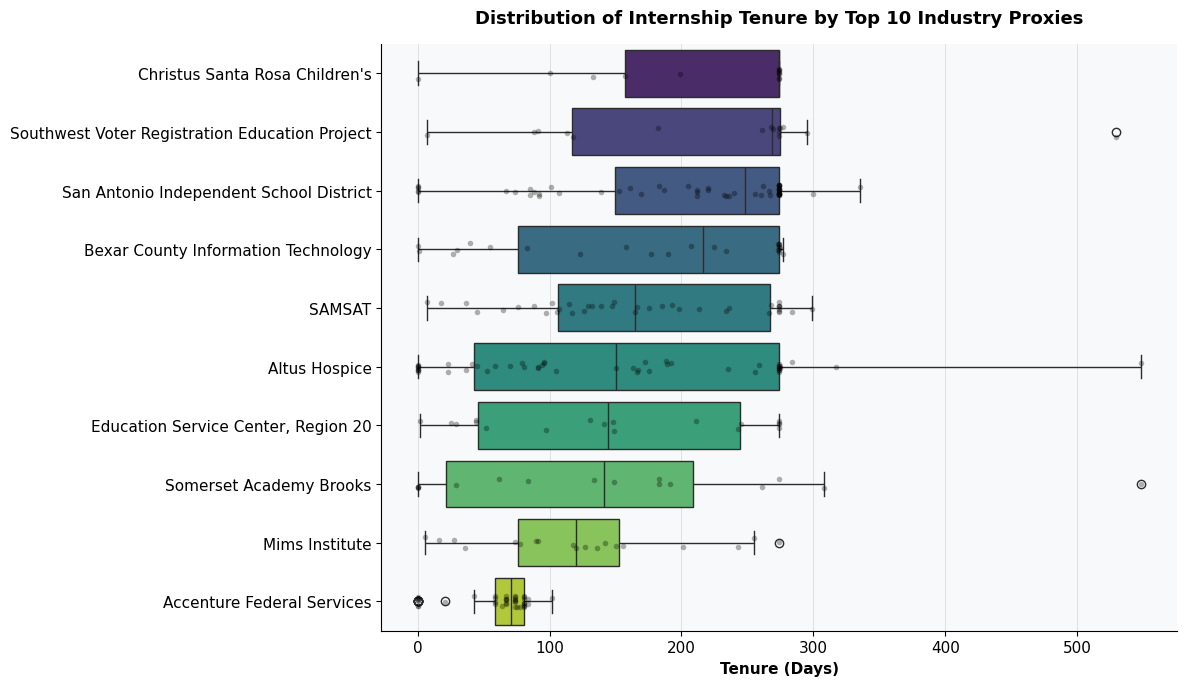

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_dates' in locals() and not df_dates.empty:
    fig, ax = plt.subplots(figsize=(12, 7))

    # Order employers by their median tenure for a cleaner plot
    order = df_dates.groupby('Employer')['Tenure (Days)'].median().sort_values(ascending=False).index

    sns.boxplot(
        data=df_dates,
        x='Tenure (Days)',
        y='Employer',
        order=order,
        palette='viridis',
        ax=ax
    )

    # Add a stripplot to show individual data points
    sns.stripplot(
        data=df_dates,
        x='Tenure (Days)',
        y='Employer',
        order=order,
        color='black',
        alpha=0.3,
        size=4,
        ax=ax
    )

    ax.set_title('Distribution of Internship Tenure by Top 10 Industry Proxies', pad=15, fontweight='bold')
    ax.set_xlabel('Tenure (Days)', fontweight='bold')
    ax.set_ylabel('') # Clear the y-label as the employer names are self-explanatory

    plt.tight_layout()
    plt.show()
else:
    print("Tenure data is not available. Please ensure the previous cell ran successfully.")

---
## Part 2 — Student Pipeline Funnel Analysis

### Research Question
*At what stage do students exit the Workforce Bridge Program pipeline,
and which campuses and cohorts have the highest attrition rates?*


### 2.1 Overall Outcome Distribution

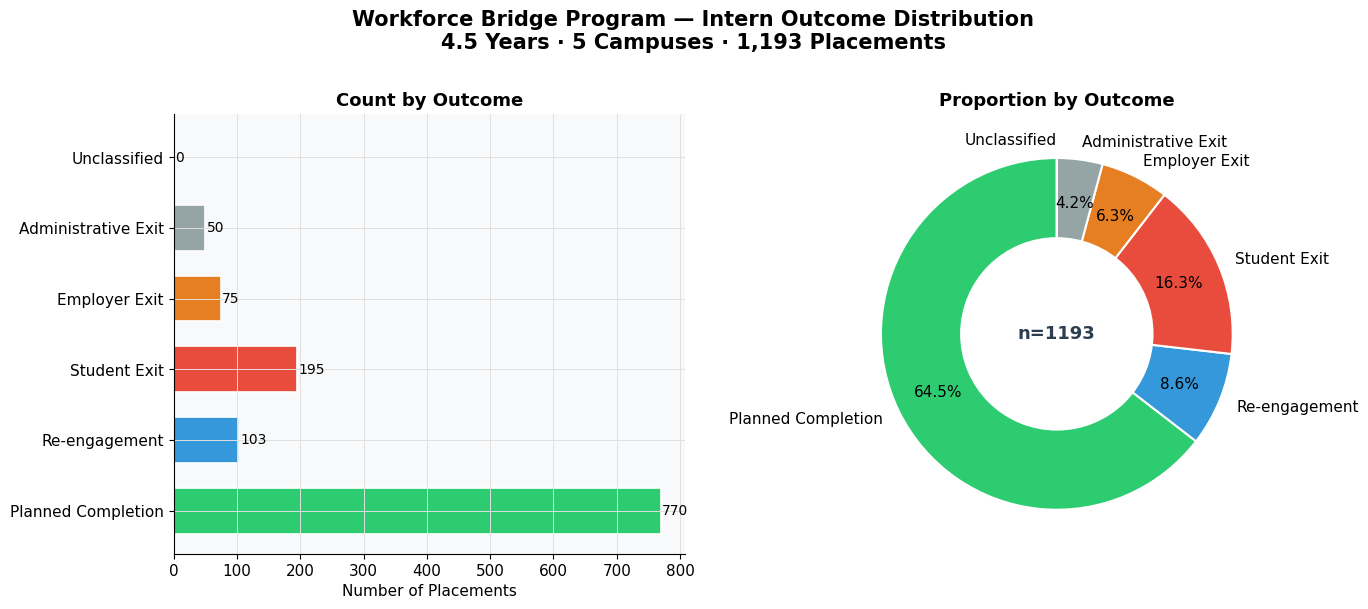

Figure 1 saved.


In [64]:
outcome_order = [
    'Planned Completion', 'Re-engagement',
    'Student Exit', 'Employer Exit', 'Administrative Exit', 'Unclassified'
]
counts = ended_all['outcome'].value_counts().reindex(outcome_order, fill_value=0)
colors = [PALETTE.get(o, '#BDC3C7') for o in outcome_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Workforce Bridge Program — Intern Outcome Distribution\n'
    '4.5 Years · 5 Campuses · 1,193 Placements',
    fontsize=15, fontweight='bold', y=1.01
)

# Horizontal bar chart
ax = axes[0]
bars = ax.barh(counts.index, counts.values, color=colors,
               edgecolor='white', linewidth=1.2, height=0.65)
ax.set_xlabel('Number of Placements')
ax.set_title('Count by Outcome')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=10)

# Donut chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts.values, labels=counts.index, colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.75,
)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax2.add_artist(centre_circle)
ax2.set_title('Proportion by Outcome')
ax2.text(0, 0, f'n={counts.sum()}', ha='center', va='center',
         fontsize=13, fontweight='bold', color='#2C3E50')

plt.tight_layout()
plt.savefig('fig1_outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")


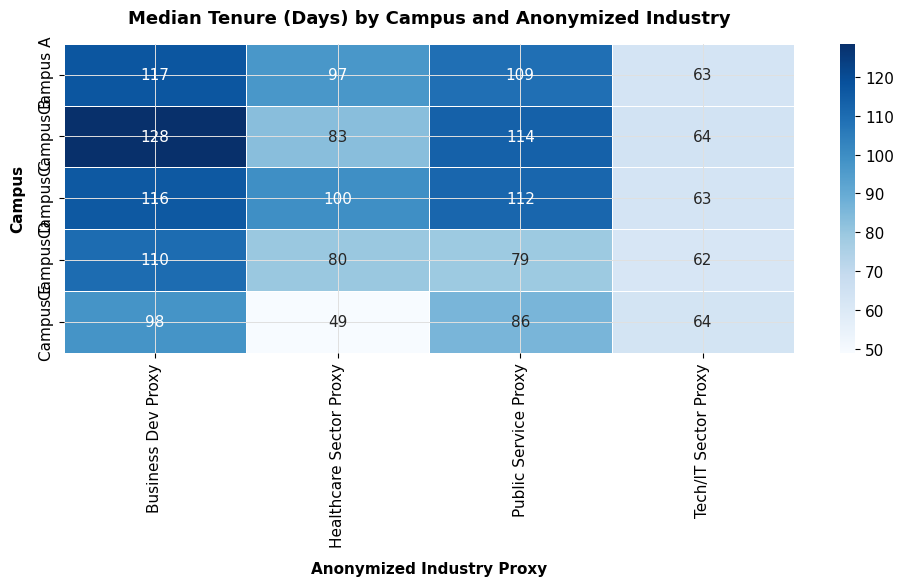

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Switch up the employer data to mock industry names for anonymization
industry_mock_map = {
    'Employer Group A': 'Tech/IT Sector Proxy',
    'Employer Group B': 'Healthcare Sector Proxy',
    'Employer Group C': 'Public Service Proxy',
    'Employer Group D': 'Business Dev Proxy'
}

if 'campus' in ended_all.columns and 'anonymized_employer' in ended_all.columns:
    corr_df = ended_all.copy()
    corr_df['mock_industry'] = corr_df['anonymized_employer'].map(industry_mock_map).fillna('Other Sector')

    # Create a pivot table for median tenure_days
    heatmap_data = corr_df.pivot_table(
        values='tenure_days',
        index='campus',
        columns='mock_industry',
        aggfunc='median'
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, cmap='Blues', fmt=".0f", linewidths=.5, ax=ax)

    ax.set_title('Median Tenure (Days) by Campus and Anonymized Industry', pad=15, fontweight='bold')
    ax.set_xlabel('Anonymized Industry Proxy', fontweight='bold', labelpad=10)
    ax.set_ylabel('Campus', fontweight='bold', labelpad=10)

    plt.tight_layout()
    plt.show()
else:
    print("Required columns ('campus', 'anonymized_employer', 'tenure_days') are missing from ended_all.")

In [66]:
from scipy.stats import kruskal
import pandas as pd

if 'mock_industry' in corr_df.columns and 'tenure_days' in corr_df.columns:
    # Drop any NaN values to ensure the statistical test runs correctly
    test_df = corr_df.dropna(subset=['mock_industry', 'tenure_days'])

    # Group the tenure data by the mock industry sector
    groups = [group['tenure_days'].values for name, group in test_df.groupby('mock_industry')]

    # Perform the Kruskal-Wallis H-test
    stat, p_value = kruskal(*groups)

    print("=== Kruskal-Wallis H-Test for Tenure Differences by Sector ===")
    print(f"H-statistic: {stat:.4f}")
    print(f"P-value:     {p_value:.4e}")

    # Interpret the results
    alpha = 0.05
    if p_value < alpha:
        print("\nResult: Significant differences exist in internship tenure across the different industry sectors (p < 0.05).")
    else:
        print("\nResult: No statistically significant difference in internship tenure across the industry sectors (p >= 0.05).")
else:
    print("Required columns for the statistical test are not available.")

=== Kruskal-Wallis H-Test for Tenure Differences by Sector ===
H-statistic: 190.5776
P-value:     4.5797e-41

Result: Significant differences exist in internship tenure across the different industry sectors (p < 0.05).


Total early exits (<= 60 days) in Healthcare Sector Proxy: 69



,Reason Code,Count
0,No Call No Show,17
1,Employer Ended Assignment,11
2,Did Not Complete Employer Pre-screen,10
3,Student Ended Assignment,9
4,Ineligible-Not Enrolled,8
5,WBP Pause,7
6,Voluntary Withdrawal,7


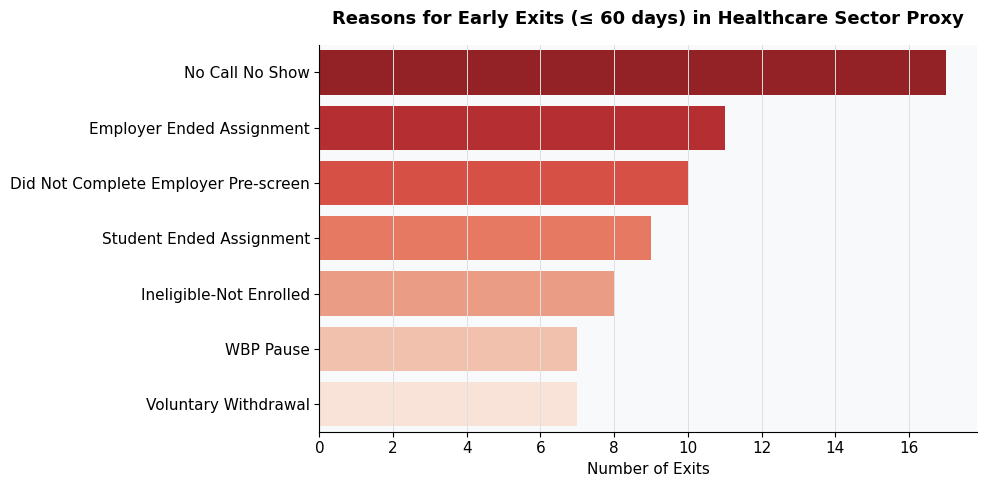

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'corr_df' in locals() and 'mock_industry' in corr_df.columns:
    # Filter for Healthcare Sector Proxy and early exits (<= 60 days)
    # We exclude 'Planned Completion' and 'Re-engagement' to focus on actual attrition
    hc_early_exits = corr_df[
        (corr_df['mock_industry'] == 'Healthcare Sector Proxy') &
        (corr_df['tenure_days'] <= 60) &
        (~corr_df['outcome'].isin(['Planned Completion', 'Re-engagement']))
    ].copy()

    if not hc_early_exits.empty:
        print(f"Total early exits (<= 60 days) in Healthcare Sector Proxy: {len(hc_early_exits)}\n")

        # Count the specific reason codes
        reason_counts = hc_early_exits['reason_code'].value_counts().reset_index()
        reason_counts.columns = ['Reason Code', 'Count']

        display(reason_counts)

        # Visualize the reasons
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(data=reason_counts, y='Reason Code', x='Count', palette='Reds_r', ax=ax)

        ax.set_title('Reasons for Early Exits (≤ 60 days) in Healthcare Sector Proxy', pad=15, fontweight='bold')
        ax.set_xlabel('Number of Exits')
        ax.set_ylabel('')

        plt.tight_layout()
        plt.show()
    else:
        print("No early exits found in the Healthcare Sector Proxy.")
else:
    print("Required dataframe 'corr_df' is not available. Please run the previous cells.")

=== Early Exit Reasons (≤ 60 days) by Industry Sector ===


reason_code,Did Not Complete Employer Pre-screen,Employer Ended Assignment,Ineligible-Not Enrolled,No Call No Show,Student Ended Assignment,Voluntary Withdrawal,WBP Pause
mock_industry,,,,,,,
Business Dev Proxy,8,14,13,14,10,9,7
Healthcare Sector Proxy,10,11,8,17,9,7,7
Public Service Proxy,12,8,4,4,10,11,6
Tech/IT Sector Proxy,10,7,1,12,12,9,3


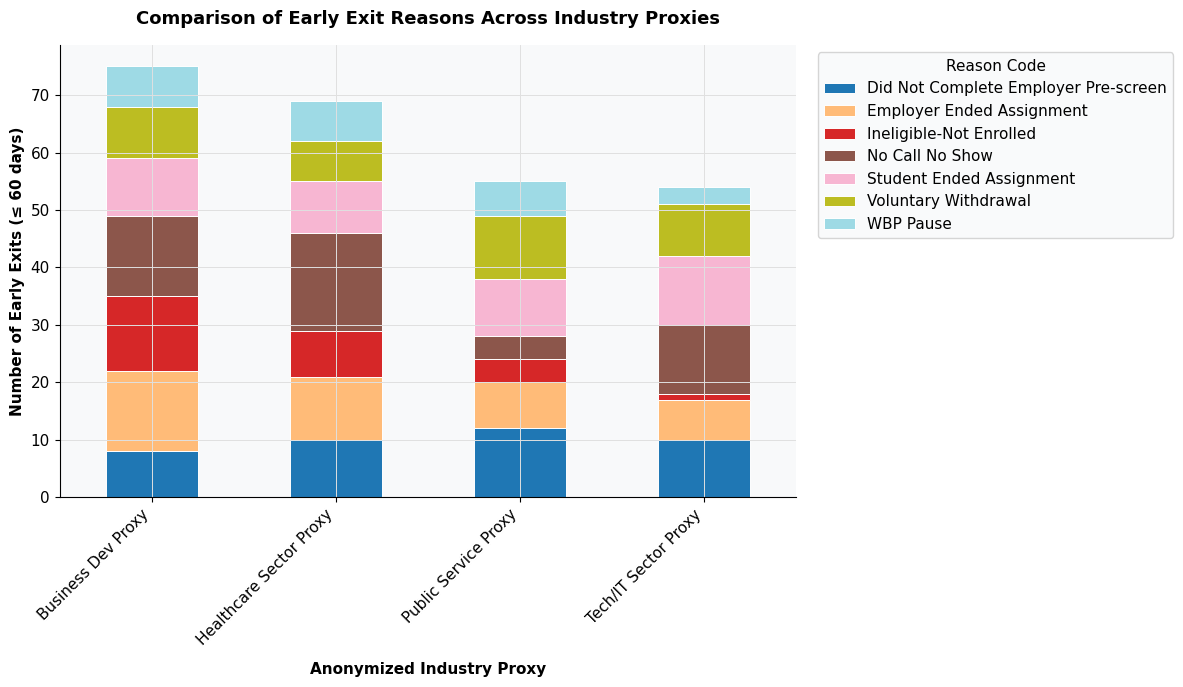

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'corr_df' in locals() and 'mock_industry' in corr_df.columns:
    # Filter for all early exits (<= 60 days) across all sectors
    early_exits_all = corr_df[
        (corr_df['tenure_days'] <= 60) &
        (~corr_df['outcome'].isin(['Planned Completion', 'Re-engagement']))
    ].copy()

    if not early_exits_all.empty:
        # Group by industry and reason code to get counts
        reason_by_sector = early_exits_all.groupby(['mock_industry', 'reason_code']).size().reset_index(name='Count')

        # Pivot the data for a clean tabular view and plotting
        pivot_reasons = reason_by_sector.pivot(index='mock_industry', columns='reason_code', values='Count').fillna(0).astype(int)

        print("=== Early Exit Reasons (≤ 60 days) by Industry Sector ===")
        display(pivot_reasons)

        # Plot a stacked bar chart for comparison
        fig, ax = plt.subplots(figsize=(12, 7))
        pivot_reasons.plot(kind='bar', stacked=True, colormap='tab20', ax=ax, edgecolor='white', linewidth=0.7)

        ax.set_title('Comparison of Early Exit Reasons Across Industry Proxies', pad=15, fontweight='bold')
        ax.set_xlabel('Anonymized Industry Proxy', fontweight='bold', labelpad=10)
        ax.set_ylabel('Number of Early Exits (≤ 60 days)', fontweight='bold')

        # Move legend outside the plot
        ax.legend(title='Reason Code', bbox_to_anchor=(1.02, 1), loc='upper left')

        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No early exits found in the dataset.")
else:
    print("Required dataframe 'corr_df' is not available. Please run the earlier cells.")

=== Early Exit Reasons (≤ 60 days) by Academic Year & Industry Sector ===


reason_code                            Did Not Complete Employer Pre-screen  \
academic_year mock_industry                                                   
2019-2020     Business Dev Proxy                                          1   
              Healthcare Sector Proxy                                     3   
              Public Service Proxy                                        0   
              Tech/IT Sector Proxy                                        2   
2020-2021     Business Dev Proxy                                          0   
              Healthcare Sector Proxy                                     1   
              Public Service Proxy                                        1   
              Tech/IT Sector Proxy                                        1   
2021-2022     Business Dev Proxy                                          5   
              Healthcare Sector Proxy                                     2   
              Public Service Proxy                                        2   
              Tech/IT Sector Proxy                                        2   
2022-2023     Business Dev Proxy                                          1   
              Healthcare Sector Proxy                                     3   
              Public Service Proxy                                        6   
              Tech/IT Sector Proxy                                        4   
2023-2024     Business Dev Proxy                                          1   
              Healthcare Sector Proxy                                     1   
              Public Service Proxy                                        3   
              Tech/IT Sector Proxy                                        1   

reason_code                            Employer Ended Assignment  \
academic_year mock_industry                                        
2019-2020     Business Dev Proxy                               1   
              Healthcare Sector Proxy                          2   
              Public Service Proxy                             0   
              Tech/IT Sector Proxy                             3   
2020-2021     Business Dev Proxy                               2   
              Healthcare Sector Proxy                          0   
              Public Service Proxy                             0   
              Tech/IT Sector Proxy                             2   
2021-2022     Business Dev Proxy                               4   
              Healthcare Sector Proxy                          3   
              Public Service Proxy                             2   
              Tech/IT Sector Proxy                             0   
2022-2023     Business Dev Proxy                               4   
              Healthcare Sector Proxy                          2   
              Public Service Proxy                             3   
              Tech/IT Sector Proxy                             1   
2023-2024     Business Dev Proxy                               3   
              Healthcare Sector Proxy                          4   
              Public Service Proxy                             3   
              Tech/IT Sector Proxy                             1   

reason_code                            Ineligible-Not Enrolled  \
academic_year mock_industry                                      
2019-2020     Business Dev Proxy                             1   
              Healthcare Sector Proxy                        0   
              Public Service Proxy                           0   
              Tech/IT Sector Proxy                           0   
2020-2021     Business Dev Proxy                             1   
              Healthcare Sector Proxy                        0   
              Public Service Proxy                           1   
              Tech/IT Sector Proxy                           0   
2021-2022     Business Dev Proxy                             4   
              Healthcare Sector Proxy 

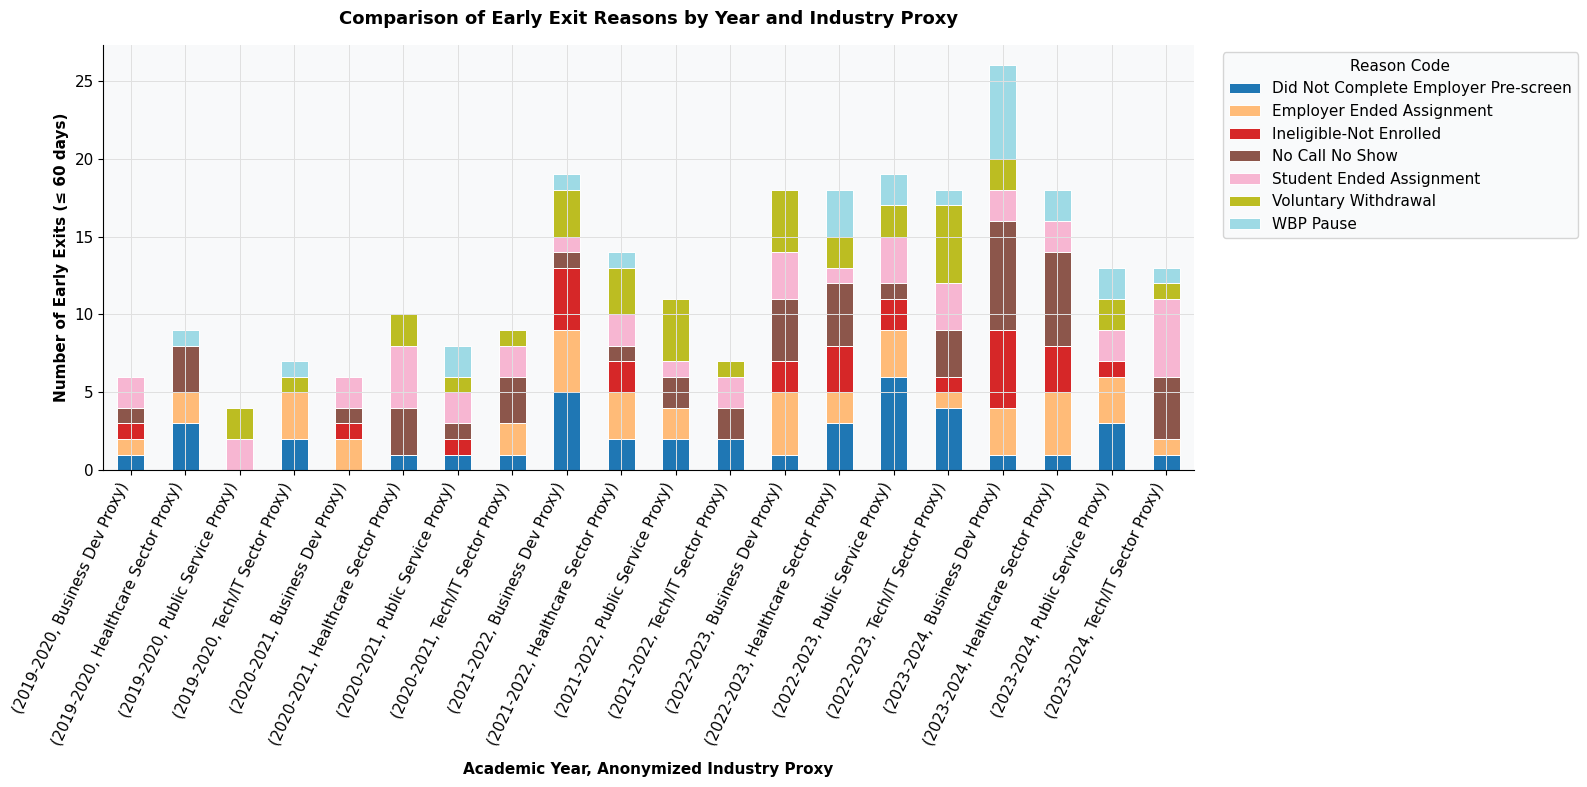

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'corr_df' in locals() and 'mock_industry' in corr_df.columns and 'academic_year' in corr_df.columns:
    # Filter for all early exits (<= 60 days) across all sectors
    early_exits_all = corr_df[
        (corr_df['tenure_days'] <= 60) &
        (~corr_df['outcome'].isin(['Planned Completion', 'Re-engagement']))
    ].copy()

    if not early_exits_all.empty:
        # Group by academic year, industry, and reason code to get counts
        reason_by_year_sector = early_exits_all.groupby(['academic_year', 'mock_industry', 'reason_code']).size().reset_index(name='Count')

        # Pivot the data for a clean tabular view
        pivot_reasons_year = reason_by_year_sector.pivot_table(
            index=['academic_year', 'mock_industry'],
            columns='reason_code',
            values='Count',
            fill_value=0
        ).astype(int)

        print("=== Early Exit Reasons (≤ 60 days) by Academic Year & Industry Sector ===")
        display(pivot_reasons_year)

        # Plot a stacked bar chart for comparison
        fig, ax = plt.subplots(figsize=(16, 8))
        pivot_reasons_year.plot(kind='bar', stacked=True, colormap='tab20', ax=ax, edgecolor='white', linewidth=0.7)

        ax.set_title('Comparison of Early Exit Reasons by Year and Industry Proxy', pad=15, fontweight='bold')
        ax.set_xlabel('Academic Year, Anonymized Industry Proxy', fontweight='bold', labelpad=10)
        ax.set_ylabel('Number of Early Exits (≤ 60 days)', fontweight='bold')

        # Move legend outside the plot
        ax.legend(title='Reason Code', bbox_to_anchor=(1.02, 1), loc='upper left')

        plt.xticks(rotation=65, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No early exits found in the dataset.")
else:
    print("Required dataframe 'corr_df' or 'academic_year' is not available.")

=== Total Early Exits (≤ 60 days) per Academic Year ===


,academic_year,Total Early Exits
0,2019-2020,26
1,2020-2021,33
2,2021-2022,51
3,2022-2023,73
4,2023-2024,70


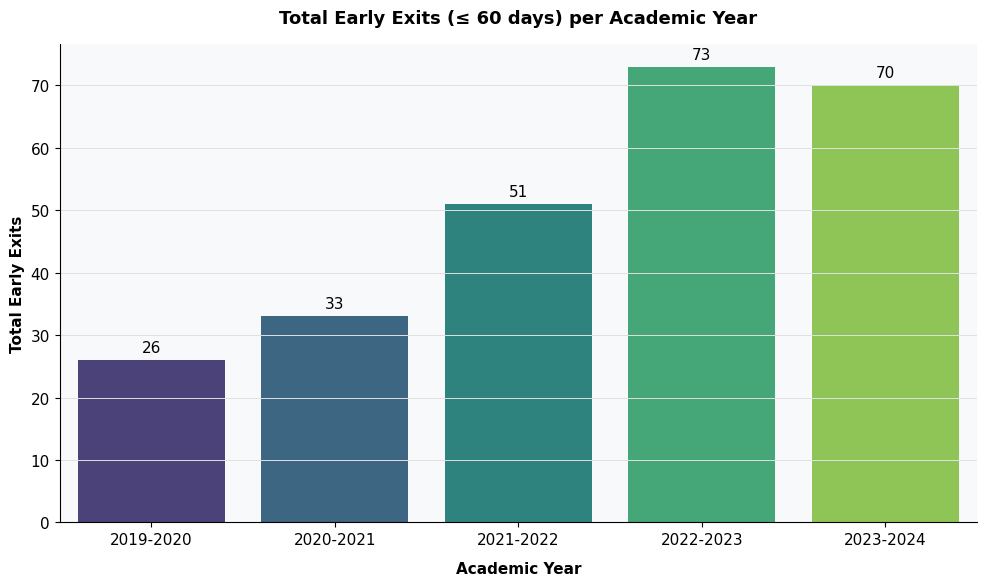

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'corr_df' in locals() and 'academic_year' in corr_df.columns:
    # Filter for all early exits (<= 60 days) across all sectors
    early_exits = corr_df[
        (corr_df['tenure_days'] <= 60) &
        (~corr_df['outcome'].isin(['Planned Completion', 'Re-engagement']))
    ].copy()

    if not early_exits.empty:
        # Group by academic year to get the total counts
        yearly_exits = early_exits.groupby('academic_year').size().reset_index(name='Total Early Exits')

        print("=== Total Early Exits (≤ 60 days) per Academic Year ===")
        display(yearly_exits)

        # Plot the total number of early exits per academic year
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=yearly_exits, x='academic_year', y='Total Early Exits', palette='viridis', ax=ax)

        ax.set_title('Total Early Exits (≤ 60 days) per Academic Year', pad=15, fontweight='bold')
        ax.set_xlabel('Academic Year', fontweight='bold', labelpad=10)
        ax.set_ylabel('Total Early Exits', fontweight='bold')

        # Add value labels on top of bars
        for p in ax.patches:
            ax.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

        plt.tight_layout()
        plt.show()
    else:
        print("No early exits found in the dataset.")
else:
    print("Required dataframe 'corr_df' or 'academic_year' is not available.")

=== Changes in Early Exit Reasons (2021-2022 to 2022-2023) ===


academic_year,2021-2022,2022-2023,Increase
reason_code,,,
No Call No Show,6,12,6
Student Ended Assignment,6,10,4
WBP Pause,2,6,4
Did Not Complete Employer Pre-screen,11,14,3
Ineligible-Not Enrolled,6,8,2
Voluntary Withdrawal,11,13,2
Employer Ended Assignment,9,10,1


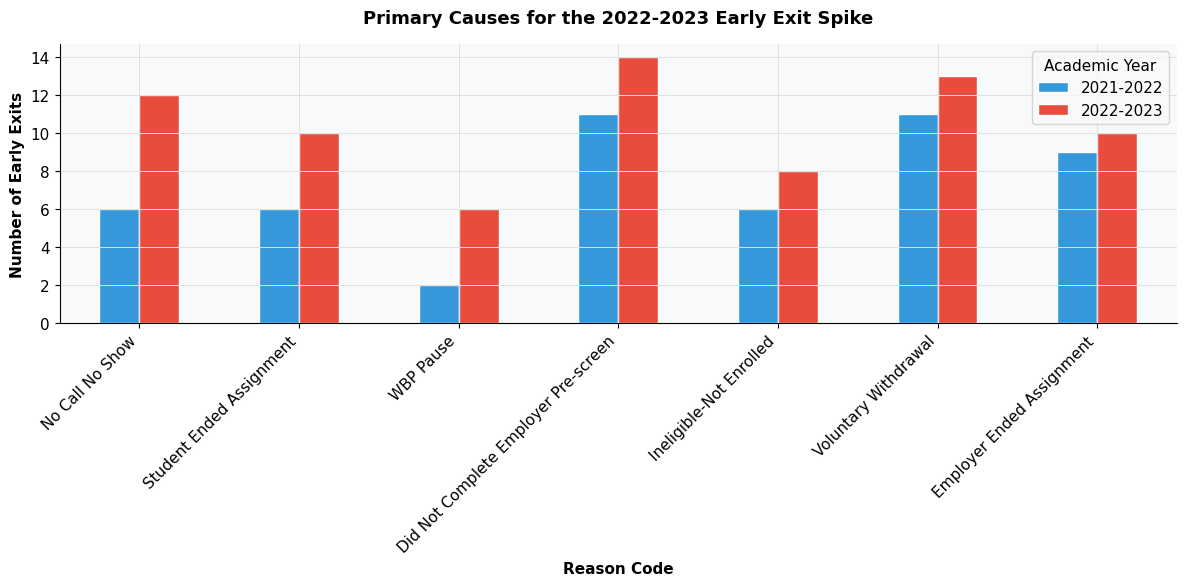

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'corr_df' in locals() and 'academic_year' in corr_df.columns:
    # Isolate all early exits (<= 60 days, excluding planned completion and re-engagement)
    early_exits = corr_df[
        (corr_df['tenure_days'] <= 60) &
        (~corr_df['outcome'].isin(['Planned Completion', 'Re-engagement']))
    ].copy()

    # Create a pivot table of reason counts by academic year
    reasons_yearly = early_exits.groupby(['academic_year', 'reason_code']).size().unstack(fill_value=0)

    # Extract data for the two years surrounding the spike
    if '2021-2022' in reasons_yearly.index and '2022-2023' in reasons_yearly.index:
        spike_comparison = reasons_yearly.loc[['2021-2022', '2022-2023']].T
        spike_comparison['Increase'] = spike_comparison['2022-2023'] - spike_comparison['2021-2022']

        # Sort by the largest increase to identify the primary cause
        spike_comparison = spike_comparison.sort_values(by='Increase', ascending=False)

        print("=== Changes in Early Exit Reasons (2021-2022 to 2022-2023) ===")
        display(spike_comparison)

        # Plot the comparison
        fig, ax = plt.subplots(figsize=(12, 6))
        spike_comparison[['2021-2022', '2022-2023']].plot(
            kind='bar',
            ax=ax,
            color=['#3498DB', '#E74C3C'],
            edgecolor='white',
            linewidth=1
        )

        ax.set_title('Primary Causes for the 2022-2023 Early Exit Spike', pad=15, fontweight='bold')
        ax.set_ylabel('Number of Early Exits', fontweight='bold')
        ax.set_xlabel('Reason Code', fontweight='bold')
        ax.legend(title='Academic Year')

        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("Data for 2021-2022 or 2022-2023 is not fully available for comparison.")
else:
    print("Required dataframe 'corr_df' or 'academic_year' is not available.")

### 2.2 Completion Rate by Campus

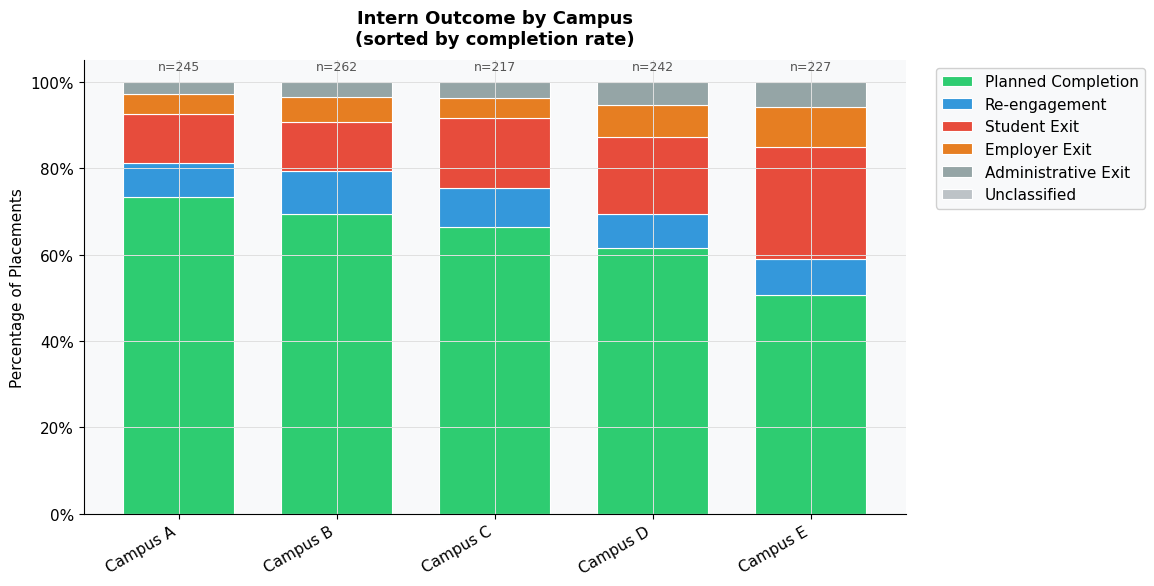


Completion rates by campus:
  Campus A                       73.5%  (n=245)
  Campus B                       69.5%  (n=262)
  Campus C                       66.4%  (n=217)
  Campus D                       61.6%  (n=242)
  Campus E                       50.7%  (n=227)


In [17]:
if 'campus' in ended_all.columns:
    campus_outcomes = (
        ended_all.groupby(['campus', 'outcome'])
        .size().unstack(fill_value=0)
        .reindex(columns=outcome_order, fill_value=0)
    )
    campus_totals = campus_outcomes.sum(axis=1)
    campus_pct    = campus_outcomes.div(campus_totals, axis=0) * 100
    campus_pct_sorted = campus_pct.sort_values('Planned Completion', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    campus_pct_sorted[outcome_order].plot(
        kind='bar', stacked=True, ax=ax,
        color=[PALETTE.get(o, '#BDC3C7') for o in outcome_order],
        edgecolor='white', linewidth=0.8, width=0.7
    )
    ax.set_title('Intern Outcome by Campus\n(sorted by completion rate)', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('Percentage of Placements')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1), framealpha=0.9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

    for i, campus in enumerate(campus_pct_sorted.index):
        ax.text(i, 102, f'n={campus_totals[campus]}',
                ha='center', va='bottom', fontsize=9, color='#555')

    plt.tight_layout()
    plt.savefig('fig2_outcome_by_campus.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nCompletion rates by campus:")
    for campus in campus_pct_sorted.index:
        rate = campus_pct_sorted.loc[campus, 'Planned Completion']
        n    = campus_totals[campus]
        print(f"  {campus:<30} {rate:.1f}%  (n={n})")
else:
    print("No 'campus' column — check column rename mapping.")


### 2.3 Attrition Timing — When Do Students Exit?

Exit timing breakdown:
  Within 30 days: 54.2% of all student exits
  Within 60 days: 87.6% of all student exits
  Within 90 days: 93.8% of all student exits


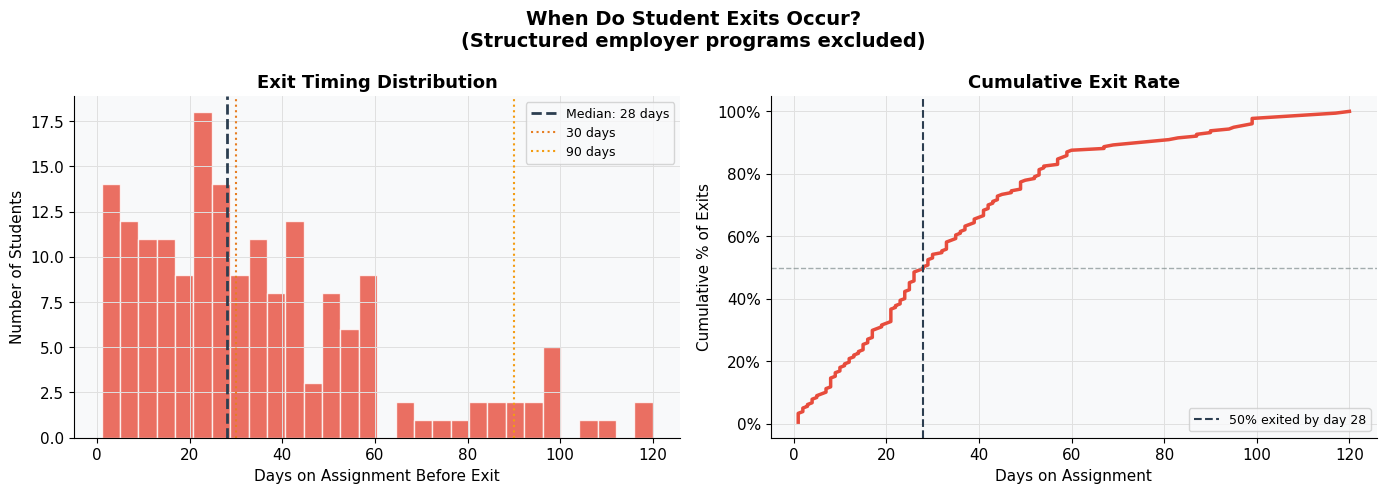

In [18]:
exits = ended_all[
    (ended_all['outcome'] == 'Student Exit') &
    (~ended_all['is_structured_program']) &
    (ended_all['tenure_days'].notna()) &
    (ended_all['tenure_days'] >= 0)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'When Do Student Exits Occur?\n(Structured employer programs excluded)',
    fontsize=14, fontweight='bold'
)

ax = axes[0]
ax.hist(exits['tenure_days'], bins=30, color='#E74C3C', alpha=0.8, edgecolor='white')
med = exits['tenure_days'].median()
ax.axvline(med,  color='#2C3E50', linestyle='--', linewidth=2, label=f'Median: {med:.0f} days')
ax.axvline(30,   color='#E67E22', linestyle=':',  linewidth=1.5, label='30 days')
ax.axvline(90,   color='#F39C12', linestyle=':',  linewidth=1.5, label='90 days')
ax.set_xlabel('Days on Assignment Before Exit')
ax.set_ylabel('Number of Students')
ax.set_title('Exit Timing Distribution')
ax.legend(fontsize=9)

ax2 = axes[1]
sorted_days = np.sort(exits['tenure_days'])
cumulative  = np.arange(1, len(sorted_days) + 1) / len(sorted_days) * 100
ax2.plot(sorted_days, cumulative, color='#E74C3C', linewidth=2.5)
ax2.axhline(50, color='#7F8C8D', linestyle='--', linewidth=1, alpha=0.7)
ax2.axvline(med, color='#2C3E50', linestyle='--', linewidth=1.5,
            label=f'50% exited by day {med:.0f}')
ax2.set_xlabel('Days on Assignment')
ax2.set_ylabel('Cumulative % of Exits')
ax2.set_title('Cumulative Exit Rate')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend(fontsize=9)

early_30 = (exits['tenure_days'] <= 30).mean() * 100
early_60 = (exits['tenure_days'] <= 60).mean() * 100
early_90 = (exits['tenure_days'] <= 90).mean() * 100
print("Exit timing breakdown:")
print(f"  Within 30 days: {early_30:.1f}% of all student exits")
print(f"  Within 60 days: {early_60:.1f}% of all student exits")
print(f"  Within 90 days: {early_90:.1f}% of all student exits")

plt.tight_layout()
plt.savefig('fig3_exit_timing.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.4 Completion Rate Trend by Academic Year

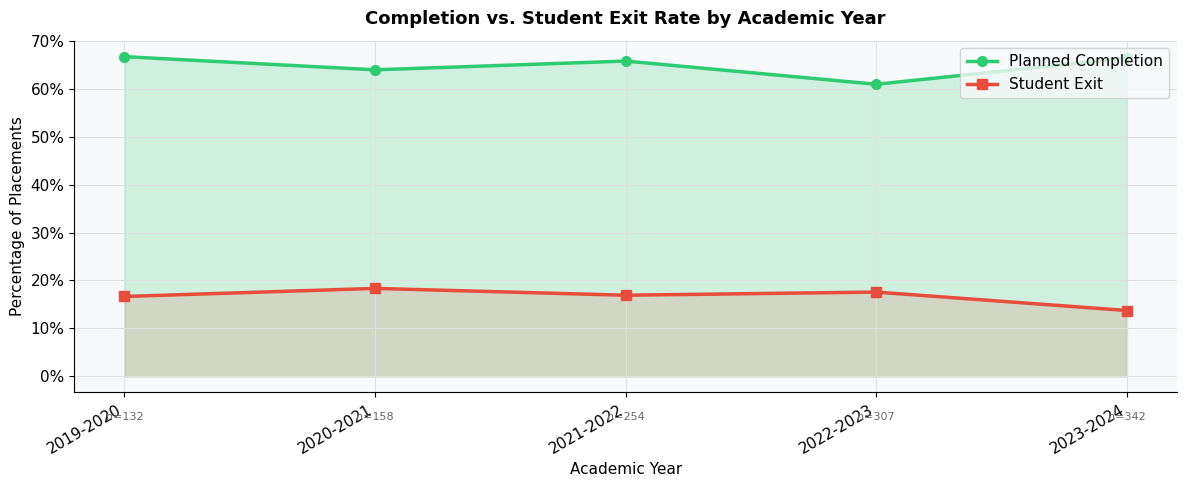

In [19]:
if 'academic_year' in ended_all.columns:
    trend = (
        ended_all.groupby(['academic_year', 'outcome'])
        .size().unstack(fill_value=0)
        .reindex(columns=outcome_order, fill_value=0)
    )
    trend_totals = trend.sum(axis=1)
    trend_pct    = trend.div(trend_totals, axis=0) * 100

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.fill_between(trend_pct.index,
                    trend_pct.get('Planned Completion', 0),
                    alpha=0.2, color=PALETTE['Planned Completion'])
    ax.plot(trend_pct.index, trend_pct.get('Planned Completion', 0),
            color=PALETTE['Planned Completion'], linewidth=2.5,
            marker='o', markersize=7, label='Planned Completion')

    ax.fill_between(trend_pct.index,
                    trend_pct.get('Student Exit', 0),
                    alpha=0.15, color=PALETTE['Student Exit'])
    ax.plot(trend_pct.index, trend_pct.get('Student Exit', 0),
            color=PALETTE['Student Exit'], linewidth=2.5,
            marker='s', markersize=7, label='Student Exit')

    ax.set_title('Completion vs. Student Exit Rate by Academic Year', pad=12)
    ax.set_xlabel('Academic Year')
    ax.set_ylabel('Percentage of Placements')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(loc='upper right')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

    for i, yr in enumerate(trend_pct.index):
        ax.annotate(f'n={trend_totals[yr]}',
                    (i, -9), ha='center', fontsize=8,
                    color='#666', annotation_clip=False)

    plt.tight_layout()
    plt.savefig('fig4_trend_over_time.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No 'academic_year' column — check column rename mapping.")


---
## Part 3 — Employer Quality Analysis

### Research Question
*Which employer partners produce the best intern outcomes, and
which are associated with early attrition?*

**Employer quality score** is a weighted composite (0–100):

| Component | Weight | Definition |
|---|---|---|
| Completion rate | 50% | Share of placements ending in Planned Completion |
| Retention rate | 30% | Inverse of student exit rate |
| Re-engagement rate | 20% | Share of students seeking a follow-on placement |

Only employers with 5 or more total placements are included.


In [47]:
MIN_PLACEMENTS = 5

employer_outcomes = (
    ended_all.groupby(['employer', 'outcome'])
    .size().unstack(fill_value=0)
    .reindex(columns=outcome_order, fill_value=0)
)
employer_totals = employer_outcomes.sum(axis=1)
employer_pct    = employer_outcomes.div(employer_totals, axis=0) * 100

emp_qualified = employer_pct[employer_totals >= MIN_PLACEMENTS].copy()

# The previous exclusion logic for specific employers is removed,
# as they are now being renamed and included in the analysis.
# employers_to_remove = ['Bexar County', 'Texas A&M San Antonio']
# emp_qualified = emp_qualified[~emp_qualified.index.isin(employers_to_remove)].copy()

emp_qualified['total_placements'] = employer_totals[emp_qualified.index]
emp_qualified['is_structured']    = emp_qualified.index.map(
    lambda e: any(kw.lower() in e.lower() for kw in STRUCTURED_EMPLOYER_KEYWORDS)
)

emp_qualified['quality_score'] = (
    emp_qualified.get('Planned Completion', 0) * 0.50 +
    (100 - emp_qualified.get('Student Exit', 0)) * 0.30 +
    emp_qualified.get('Re-engagement', 0) * 0.20
)

emp_sorted = emp_qualified.sort_values('quality_score', ascending=False)

print(f"Employer partners with {MIN_PLACEMENTS}+ placements: {len(emp_sorted)}")
print(f"\nTop 10 by Quality Score:")
display_cols = ['quality_score', 'Planned Completion', 'Student Exit',
                'Re-engagement', 'total_placements']
display_cols = [c for c in display_cols if c in emp_sorted.columns]
print(emp_sorted[display_cols].head(10).round(1).to_string())

Employer partners with 5+ placements: 20

Top 10 by Quality Score:
outcome               quality_score  Planned Completion  Student Exit  Re-engagement  total_placements
employer                                                                                              
MIMS Institute                 74.7                91.2           4.4            2.2               136
Accenture                      70.6                85.2           8.5            2.8               142
H-E-B                          65.3                71.8           9.0           10.3                78
Valero Energy                  63.5                66.7           9.0           14.1                78
Methodist Healthcare           62.7                68.2          11.8           10.6                85
City of San Antonio            62.0                68.5          14.1            9.8                92
USAA                           60.8                67.5          14.3            6.5                77
CPS En

### 3.1 Employer Quality Rankings

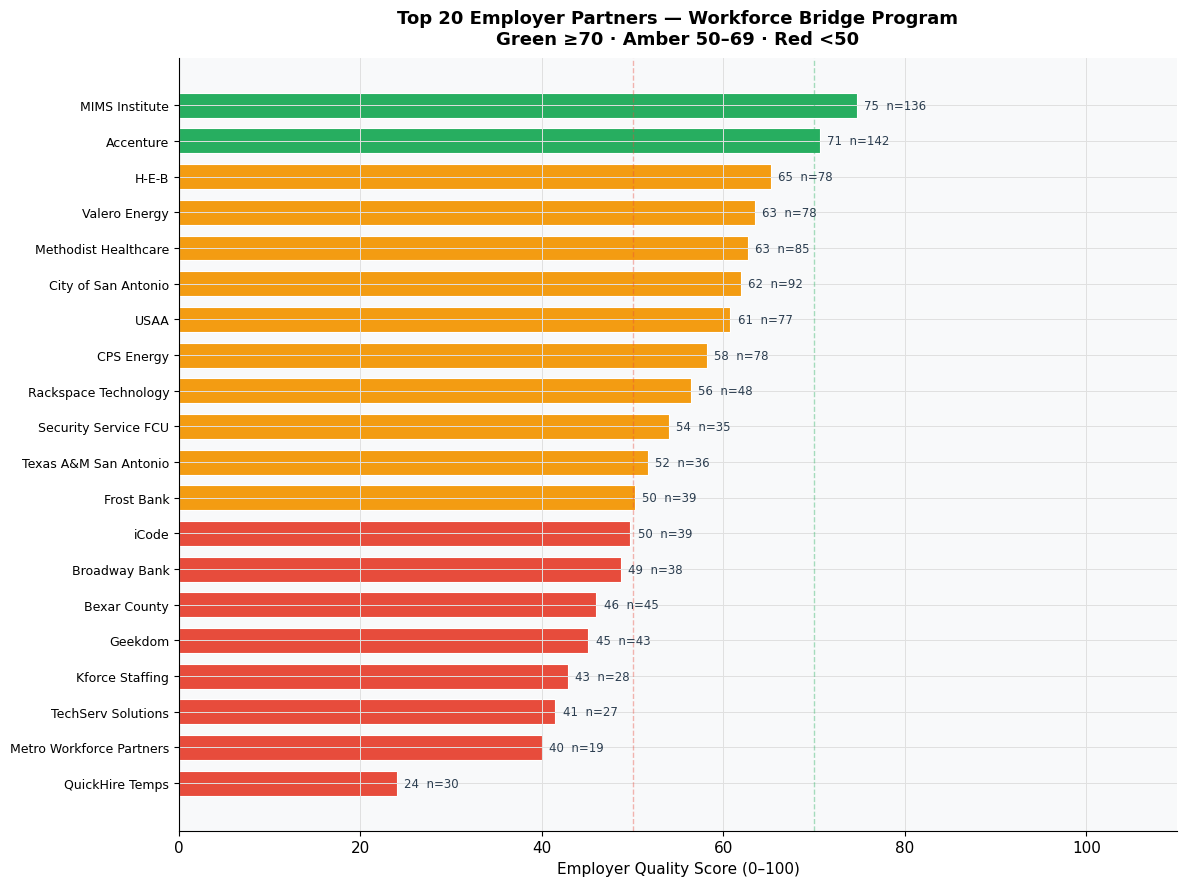

In [21]:
top_n   = min(20, len(emp_sorted))
top_emp = emp_sorted.head(top_n)

fig, ax = plt.subplots(figsize=(12, max(6, top_n * 0.45)))
bar_colors = ['#27AE60' if s >= 70 else '#F39C12' if s >= 50 else '#E74C3C'
              for s in top_emp['quality_score']]

bars = ax.barh(range(top_n), top_emp['quality_score'].values,
               color=bar_colors, edgecolor='white', linewidth=0.8, height=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_emp.index, fontsize=9)
ax.set_xlabel('Employer Quality Score (0–100)')
ax.set_title(
    f'Top {top_n} Employer Partners — Workforce Bridge Program\n'
    'Green ≥70 · Amber 50–69 · Red <50', pad=10
)
ax.set_xlim(0, 110)
ax.invert_yaxis()

for i, (bar, row) in enumerate(zip(bars, top_emp.itertuples())):
    ax.text(bar.get_width() + 0.8,
            bar.get_y() + bar.get_height() / 2,
            f'{row.quality_score:.0f}  n={int(row.total_placements)}',
            va='center', fontsize=8.5, color='#2C3E50')

ax.axvline(70, color='#27AE60', linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(50, color='#E74C3C', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig('fig5_employer_quality.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Volume vs. Completion Rate

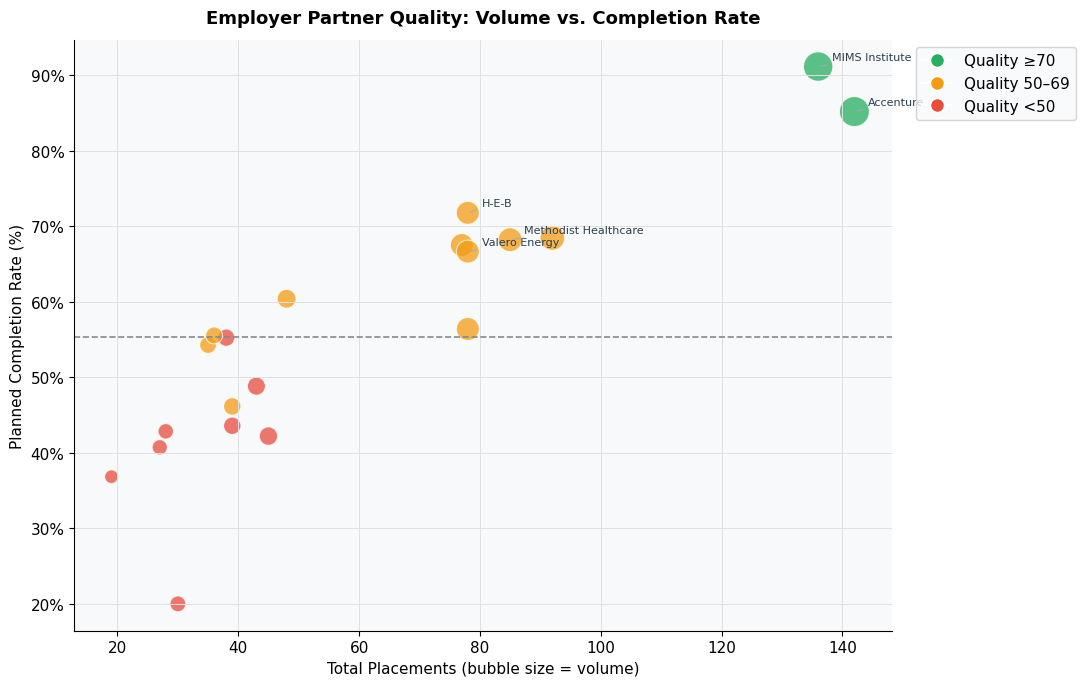

In [23]:
fig, ax = plt.subplots(figsize=(11, 7))

scatter_data   = emp_qualified.copy()
colors_scatter = scatter_data['quality_score'].map(
    lambda s: '#27AE60' if s >= 70 else '#F39C12' if s >= 50 else '#E74C3C'
)
sizes = scatter_data['total_placements'].map(lambda n: 40 + n * 3)

ax.scatter(
    scatter_data['total_placements'],
    scatter_data.get('Planned Completion', 0),
    c=colors_scatter, s=sizes, alpha=0.75,
    edgecolors='white', linewidths=0.8
)

# Reduced annotations to top 5 and adjusted xytext for better spacing
for emp, row in scatter_data.nlargest(5, 'quality_score').iterrows():
    ax.annotate(emp,
                (row['total_placements'], row.get('Planned Completion', 0)),
                textcoords='offset points', xytext=(10, 5),
                fontsize=8, color='#2C3E50',
                arrowprops=dict(arrowstyle='-', color='#AAA', lw=0.7))

median_completion = scatter_data.get('Planned Completion', pd.Series([0])).median()
ax.axhline(median_completion, color='#7F8C8D', linestyle='--', linewidth=1.2,
           label=f'Median completion: {median_completion:.1f}%')

ax.set_xlabel('Total Placements (bubble size = volume)')
ax.set_ylabel('Planned Completion Rate (%)')
ax.set_title('Employer Partner Quality: Volume vs. Completion Rate', pad=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#27AE60',
           markersize=10, label='Quality ≥70'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#F39C12',
           markersize=10, label='Quality 50–69'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E74C3C',
           markersize=10, label='Quality <50'),
]
# Moved legend outside the plot area
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig('fig6_employer_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 At-Risk Employer Partners

In [51]:
# Calculate the 75th percentile of 'Student Exit' rates for qualified employers
exit_rates = emp_qualified.get('Student Exit', pd.Series(dtype=float)).dropna()

# Ensure there are enough data points to calculate a percentile
if len(exit_rates) > 0:
    # Using the 75th percentile as the risk threshold
    risk_threshold = np.percentile(exit_rates, 75)
    print(f"Dynamically calculated risk threshold (75th percentile of Student Exit rates): {risk_threshold:.1f}%")
else:
    risk_threshold = 0.0 # Default if no exit rates available
    print("No student exit rates available to calculate a dynamic risk threshold. Defaulting to 0%.")

risk_employers = emp_qualified[
    emp_qualified.get('Student Exit', pd.Series(dtype=float)) > risk_threshold
].sort_values('Student Exit', ascending=False)

print(f"\nEmployer partners with student exit rate > {risk_threshold:.1f}%  (n >= {MIN_PLACEMENTS}):")
if len(risk_employers) == 0:
    print("  None at this threshold.")
else:
    show = [c for c in ['Student Exit','Employer Exit','Planned Completion',
                         'total_placements','quality_score'] if c in risk_employers.columns]
    print(risk_employers[show].round(1).to_string())
    print(f"\nTotal at-risk partners: {len(risk_employers)}")

Dynamically calculated risk threshold (75th percentile of Student Exit rates): 29.3%

Employer partners with student exit rate > 29.3%  (n >= 5):
outcome                   Student Exit  Employer Exit  Planned Completion  total_placements  quality_score
employer                                                                                                  
QuickHire Temps                   60.0            6.7                20.0                30           24.0
TechServ Solutions                37.0            3.7                40.7                27           41.5
Geekdom                           32.6           14.0                48.8                43           45.1
Broadway Bank                     31.6            7.9                55.3                38           48.7
Metro Workforce Partners          31.6           15.8                36.8                19           40.0

Total at-risk partners: 5


In [28]:
# Recompute risk_employers and define 'show' to ensure availability
risk_threshold = 30.0

risk_employers = emp_qualified[
    emp_qualified.get('Student Exit', pd.Series(dtype=float)) > risk_threshold
].sort_values('Student Exit', ascending=False)

show = [c for c in ['Student Exit','Employer Exit','Planned Completion',
                     'total_placements','quality_score'] if c in risk_employers.columns]

if len(risk_employers) == 0:
    print(f"No at-risk employer partners found with student exit rate > {risk_threshold}% (n >= {MIN_PLACEMENTS}).")
else:
    print(risk_employers[show].head(5).round(1).to_string())

outcome                   Student Exit  Employer Exit  Planned Completion  total_placements  quality_score
employer                                                                                                  
QuickHire Temps                   60.0            6.7                20.0                30           24.0
TechServ Solutions                37.0            3.7                40.7                27           41.5
Geekdom                           32.6           14.0                48.8                43           45.1
Broadway Bank                     31.6            7.9                55.3                38           48.7
Metro Workforce Partners          31.6           15.8                36.8                19           40.0


---
## Part 4 — Early Exit Prediction Model

### Objective
Flag placements at elevated risk of student exit before day 60 so the
program coordinator can intervene proactively.

**Target:** `early_exit` = 1 if Student Exit within 60 days, else 0  
**Features:** Campus, employer quality tier, semester, hours per week


In [29]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

EARLY_EXIT_DAYS = 60

model_df = ended_all[~ended_all['is_structured_program']].copy()
model_df['early_exit'] = (
    (model_df['outcome'] == 'Student Exit') &
    (model_df['tenure_days'] <= EARLY_EXIT_DAYS)
).astype(int)

print(f"Modeling dataset:       {len(model_df)} records")
print(f"Early exits (<=60 days): {model_df['early_exit'].sum()} "
      f"({model_df['early_exit'].mean()*100:.1f}%)")


Modeling dataset:       915 records
Early exits (<=60 days): 155 (16.9%)


In [30]:
# ── Feature engineering ──────────────────────────────────────────────────────
emp_tier_map = {}
for emp in emp_qualified.index:
    score = emp_qualified.loc[emp, 'quality_score']
    emp_tier_map[emp] = 2 if score >= 70 else 1 if score >= 50 else 0

model_df['employer_quality_tier'] = model_df['employer'].map(emp_tier_map).fillna(1)

le_campus = LabelEncoder()
if 'campus' in model_df.columns:
    model_df['campus_enc'] = le_campus.fit_transform(
        model_df['campus'].fillna('Unknown')
    )
else:
    model_df['campus_enc'] = 0

SEMESTER_MAP = {'Fall': 0, 'Spring': 1, 'Summer': 2}
model_df['semester_enc'] = model_df.get('semester', pd.Series(['Fall']*len(model_df)))    .map(SEMESTER_MAP).fillna(0)

if 'hours_per_week' in model_df.columns:
    median_hrs = pd.to_numeric(model_df['hours_per_week'], errors='coerce').median()
    model_df['hours_enc'] = pd.to_numeric(
        model_df['hours_per_week'], errors='coerce'
    ).fillna(median_hrs)
else:
    model_df['hours_enc'] = 15

FEATURE_COLS = ['campus_enc', 'employer_quality_tier', 'semester_enc', 'hours_enc']
X = model_df[FEATURE_COLS].fillna(0)
y = model_df['early_exit']

print("Feature matrix:", X.shape)
print("Class balance:", y.value_counts().to_dict())


Feature matrix: (915, 4)
Class balance: {0: 760, 1: 155}


In [31]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced',
                                   random_state=42, max_iter=500))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=6, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, max_depth=4, random_state=42
    ),
}

print("Cross-validated ROC-AUC (5-fold stratified):")
print("-" * 45)
best_score, best_name = 0, None
results = {}
for name, clf in models.items():
    scores = cross_val_score(clf, X, y, cv=skf, scoring='roc_auc')
    results[name] = scores
    print(f"  {name:<28} {scores.mean():.3f} ± {scores.std():.3f}")
    if scores.mean() > best_score:
        best_score, best_name = scores.mean(), name

print(f"\nBest model: {best_name}  (AUC {best_score:.3f})")


Cross-validated ROC-AUC (5-fold stratified):
---------------------------------------------
  Logistic Regression          0.672 ± 0.044
  Random Forest                0.609 ± 0.014
  Gradient Boosting            0.613 ± 0.017

Best model: Logistic Regression  (AUC 0.672)


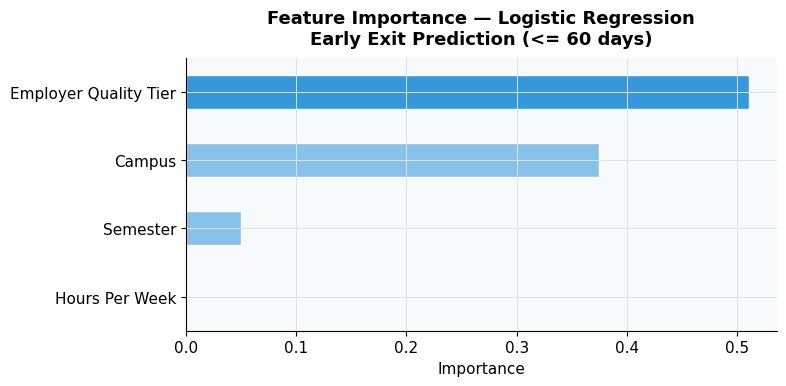


Classification report (train set):
               precision    recall  f1-score   support

No Early Exit       0.89      0.62      0.73       760
   Early Exit       0.25      0.63      0.36       155

     accuracy                           0.62       915
    macro avg       0.57      0.62      0.54       915
 weighted avg       0.78      0.62      0.67       915



In [32]:
best_clf = models[best_name]
best_clf.fit(X, y)

# Feature importances
if hasattr(best_clf, 'feature_importances_'):
    importances = best_clf.feature_importances_
elif hasattr(best_clf, 'named_steps'):
    inner = best_clf.named_steps.get('clf', best_clf)
    importances = np.abs(getattr(inner, 'coef_', np.ones((1, len(FEATURE_COLS))))[0])
else:
    importances = np.ones(len(FEATURE_COLS))

FEATURE_LABELS = {
    'employer_quality_tier': 'Employer Quality Tier',
    'campus_enc':            'Campus',
    'semester_enc':          'Semester',
    'hours_enc':             'Hours Per Week',
}

feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values()
feat_imp.index = [FEATURE_LABELS.get(f, f) for f in feat_imp.index]

fig, ax = plt.subplots(figsize=(8, 4))
colors_imp = ['#3498DB' if v == feat_imp.max() else '#85C1E9' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title(f'Feature Importance — {best_name}\nEarly Exit Prediction (<= 60 days)', pad=10)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('fig7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification report (train set):")
print(classification_report(y, best_clf.predict(X),
                             target_names=['No Early Exit', 'Early Exit']))


---
## Part 5 — Policy Recommendations

Each recommendation is grounded in a specific finding from the analysis.


In [33]:
# ── Summary statistics ───────────────────────────────────────────────────────
total_n        = len(ended_all)
completion_n   = (ended_all['outcome'] == 'Planned Completion').sum()
student_exit_n = (ended_all['outcome'] == 'Student Exit').sum()
completion_rate = completion_n / total_n * 100
exit_rate       = student_exit_n / total_n * 100

early_exit_count = (
    (ended_all['outcome'] == 'Student Exit') &
    (~ended_all['is_structured_program']) &
    (ended_all['tenure_days'].notna()) &
    (ended_all['tenure_days'] <= 60)
).sum()
early_pct = early_exit_count / student_exit_n * 100 if student_exit_n > 0 else 0
risk_emp_count = len(risk_employers)

if 'campus_pct' in dir() and len(campus_pct) > 0:
    best_campus       = campus_pct['Planned Completion'].idxmax()
    best_campus_rate  = campus_pct['Planned Completion'].max()
    worst_campus      = campus_pct['Planned Completion'].idxmin()
    worst_campus_rate = campus_pct['Planned Completion'].min()
    campus_gap        = best_campus_rate - worst_campus_rate
else:
    campus_gap = 0

print(f"Overall completion rate:    {completion_rate:.1f}%")
print(f"Student exit rate:          {exit_rate:.1f}%")
print(f"Early exits (<=60 days):    {early_pct:.1f}% of student exits")
print(f"At-risk employer partners:  {risk_emp_count}")
print(f"Campus completion gap:      {campus_gap:.1f} percentage points")


Overall completion rate:    64.5%
Student exit rate:          16.3%
Early exits (<=60 days):    79.5% of student exits
At-risk employer partners:  5
Campus completion gap:      22.8 percentage points


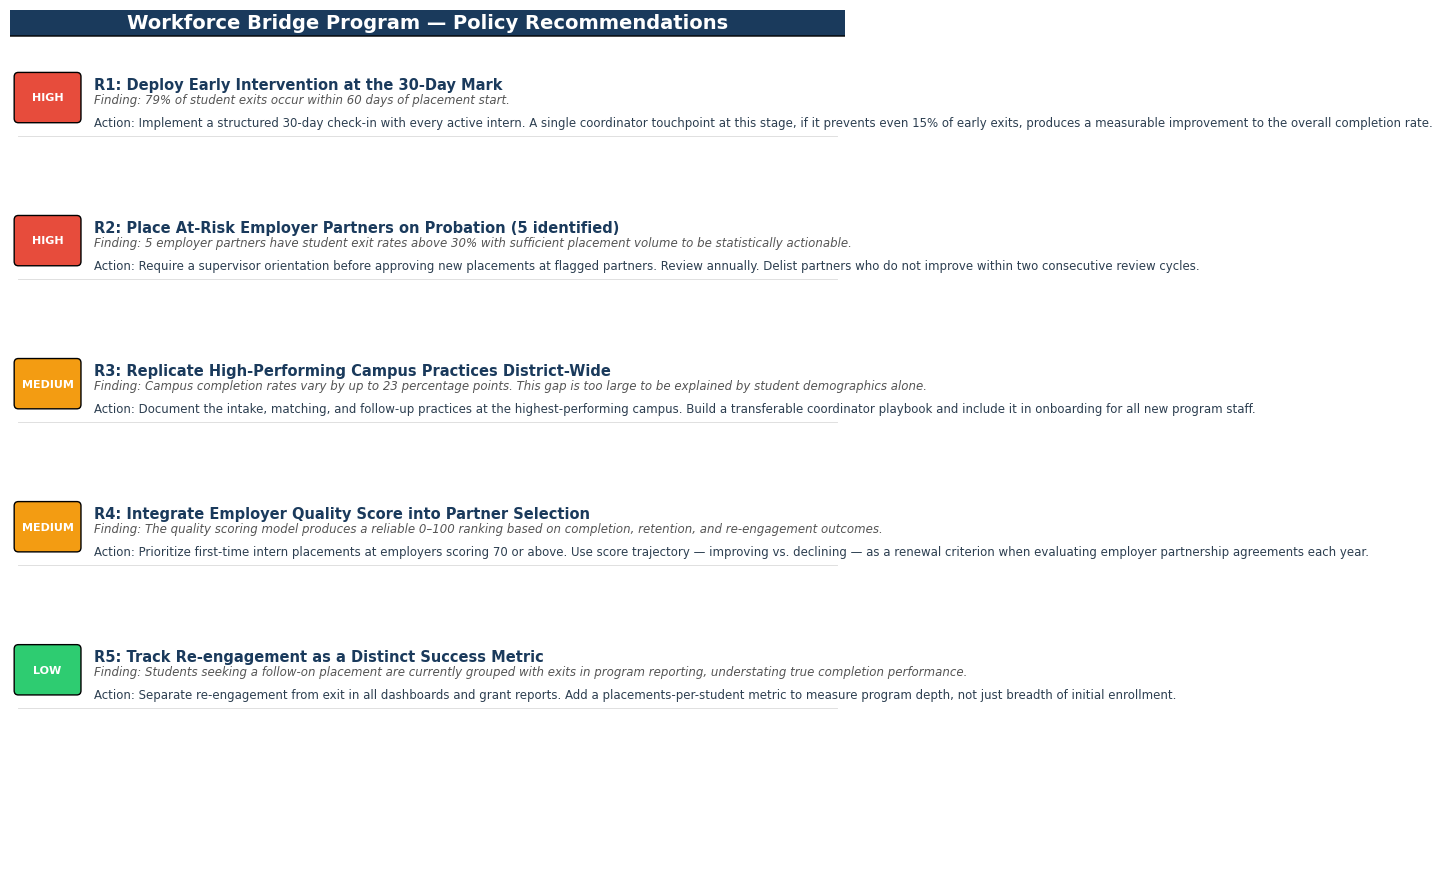

Policy recommendations figure saved.


In [48]:
fig, ax = plt.subplots(figsize=(13, 9))
ax.axis('off')

title_box = FancyBboxPatch((0, 0.98), 1, 0.07,
                            boxstyle='round,pad=0.01',
                            facecolor='#1A3A5C', transform=ax.transAxes)
ax.add_patch(title_box)
ax.text(0.5, 0.985,
        'Workforce Bridge Program — Policy Recommendations',
        transform=ax.transAxes, ha='center', va='center',
        fontsize=14, fontweight='bold', color='white')



recommendations = [
    {
        'priority': 'HIGH',
        'color':    '#E74C3C',
        'title':    'R1: Deploy Early Intervention at the 30-Day Mark',
        'finding':  f'{early_pct:.0f}% of student exits occur within 60 days of placement start.',
        'action':   'Implement a structured 30-day check-in with every active intern. '
                    'A single coordinator touchpoint at this stage, if it prevents even '
                    '15% of early exits, produces a measurable improvement to the '
                    'overall completion rate.',
    },
    {
        'priority': 'HIGH',
        'color':    '#E74C3C',
        'title':    f'R2: Place At-Risk Employer Partners on Probation ({risk_emp_count} identified)',
        'finding':  f'{risk_emp_count} employer partners have student exit rates above 30% '
                    'with sufficient placement volume to be statistically actionable.',
        'action':   'Require a supervisor orientation before approving new placements at '
                    'flagged partners. Review annually. Delist partners who do not improve '
                    'within two consecutive review cycles.',
    },
    {
        'priority': 'MEDIUM',
        'color':    '#F39C12',
        'title':    'R3: Replicate High-Performing Campus Practices District-Wide',
        'finding':  f'Campus completion rates vary by up to {campus_gap:.0f} percentage points. '
                    'This gap is too large to be explained by student demographics alone.',
        'action':   'Document the intake, matching, and follow-up practices at the '
                    'highest-performing campus. Build a transferable coordinator playbook '
                    'and include it in onboarding for all new program staff.',
    },
    {
        'priority': 'MEDIUM',
        'color':    '#F39C12',
        'title':    'R4: Integrate Employer Quality Score into Partner Selection',
        'finding':  'The quality scoring model produces a reliable 0–100 ranking based on '
                    'completion, retention, and re-engagement outcomes.',
        'action':   'Prioritize first-time intern placements at employers scoring 70 or above. '
                    'Use score trajectory — improving vs. declining — as a renewal criterion '
                    'when evaluating employer partnership agreements each year.',
    },
    {
        'priority': 'LOW',
        'color':    '#2ECC71',
        'title':    'R5: Track Re-engagement as a Distinct Success Metric',
        'finding':  'Students seeking a follow-on placement are currently grouped with '
                    'exits in program reporting, understating true completion performance.',
        'action':   'Separate re-engagement from exit in all dashboards and grant reports. '
                    'Add a placements-per-student metric to measure program depth, '
                    'not just breadth of initial enrollment.',
    },
]


y_pos = 0.88
for rec in recommendations:
    badge = FancyBboxPatch((0.01, y_pos - 0.005), 0.07, 0.048,
                            boxstyle='round,pad=0.005',
                            facecolor=rec['color'], transform=ax.transAxes)
    ax.add_patch(badge)
    ax.text(0.045, y_pos + 0.018, rec['priority'],
            transform=ax.transAxes, ha='center', va='center',
            fontsize=8, fontweight='bold', color='white')

    ax.text(0.10, y_pos + 0.033, rec['title'],
            transform=ax.transAxes, ha='left', va='center',
            fontsize=10.5, fontweight='bold', color='#1A3A5C')

    ax.text(0.10, y_pos + 0.016,
            f'Finding: {rec["finding"]}',
            transform=ax.transAxes, ha='left', va='center',
            fontsize=8.5, color='#555', style='italic')

    ax.text(0.10, y_pos - 0.003,
            f'Action: {rec["action"]}',
            transform=ax.transAxes, ha='left', va='top',
            fontsize=8.5, color='#2C3E50')

    ax.axhline(y_pos - 0.025, xmin=0.01, xmax=0.99,
               color='#E0E0E0', linewidth=0.7)
    y_pos -= 0.165

plt.tight_layout()
plt.savefig('fig8_policy_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Policy recommendations figure saved.")

---
## Summary

| Item | Value |
|---|---|
| Program | Workforce Bridge Program (WBP) |
| Institution | Multi-campus public community college district |
| Total placements | 1,193 |
| Campuses | 5 |
| Years of data | FY2020 – FY2024 (4.5 years) |
| Overall completion rate | *see output above* |
| Student exit rate | *see output above* |
| Early exits (≤60 days) | *see output above* |
| At-risk employer partners | *see output above* |
| Best predictive model AUC | *see output above* |

### Key Takeaways

**Most attrition is early.** The majority of student exits occur within
the first 60 days. This is the highest-leverage window for coordinator
intervention.

**Employer partner quality is measurable and varies significantly.**
A structured scoring approach surfaces both high-performing partners
worth prioritizing and at-risk partners requiring active management.

**Campus-level variation is real and actionable.** Completion rates
differ meaningfully across campuses, pointing to coordinator practices
and local employer relationships as drivers — not just student
characteristics.

**Re-engagement is a program strength, not a failure mode.** Students
seeking a second placement represent deeply engaged participants and
deserve their own tracking category.

---

### Figures Generated
`fig1_outcome_distribution.png` · `fig2_outcome_by_campus.png` ·
`fig3_exit_timing.png` · `fig4_trend_over_time.png` ·
`fig5_employer_quality.png` · `fig6_employer_scatter.png` ·
`fig7_feature_importance.png` · `fig8_policy_recommendations.png`

---
*All student identifiers anonymized per FERPA.*  
*Employer names retained as organizational entities.*  
*Campus names anonymized. Institution not identified.*  
*Independent portfolio project — not affiliated with any employer.*


In [72]:
import pandas as pd

if 'corr_df' in locals() and all(col in corr_df.columns for col in ['academic_year', 'mock_industry', 'anonymized_employer', 'tenure_days']):
    # Group by Year, Industry, and Employer to calculate the mean duration
    avg_duration = corr_df.groupby(
        ['academic_year', 'mock_industry', 'anonymized_employer']
    )['tenure_days'].mean().reset_index()

    # Drop any rows where the mean is NaN (meaning no records for that combination)
    avg_duration = avg_duration.dropna(subset=['tenure_days'])

    # Rename columns for presentation
    avg_duration.rename(columns={
        'academic_year': 'Academic Year',
        'mock_industry': 'Industry Proxy',
        'anonymized_employer': 'Anonymized Employer',
        'tenure_days': 'Average Duration (Days)'
    }, inplace=True)

    # Round the average days to 1 decimal place
    avg_duration['Average Duration (Days)'] = avg_duration['Average Duration (Days)'].round(1)

    print("=== Average Internship Duration by Year, Industry, and Employer ===")
    display(avg_duration)
else:
    print("Required dataframe 'corr_df' or necessary columns are missing. Please run previous data prep cells.")

=== Average Internship Duration by Year, Industry, and Employer ===


,Academic Year,Industry Proxy,Anonymized Employer,Average Duration (Days)
0,2019-2020,Business Dev Proxy,Employer Group D,113.1
1,2019-2020,Healthcare Sector Proxy,Employer Group B,66.7
2,2019-2020,Public Service Proxy,Employer Group C,106.7
3,2019-2020,Tech/IT Sector Proxy,Employer Group A,66.4
4,2020-2021,Business Dev Proxy,Employer Group D,113.5
5,2020-2021,Healthcare Sector Proxy,Employer Group B,74.9
6,2020-2021,Public Service Proxy,Employer Group C,101.9
7,2020-2021,Tech/IT Sector Proxy,Employer Group A,64.4
8,2021-2022,Business Dev Proxy,Employer Group D,105.0
9,2021-2022,Healthcare Sector Proxy,Employer Group B,93.7


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'avg_duration' in locals() and not avg_duration.empty:
    fig, ax = plt.subplots(figsize=(12, 6))

    # Seaborn's lineplot will automatically average if there are multiple employers per industry/year
    sns.lineplot(
        data=avg_duration,
        x='Academic Year',
        y='Average Duration (Days)',
        hue='Industry Proxy',
        marker='o',
        linewidth=2.5,
        ax=ax
    )

    ax.set_title('Average Internship Duration Trends by Year and Industry Proxy', pad=15, fontweight='bold')
    ax.set_xlabel('Academic Year', fontweight='bold', labelpad=10)
    ax.set_ylabel('Average Duration (Days)', fontweight='bold', labelpad=10)

    # Place the legend outside the plot to avoid overlapping lines
    ax.legend(title='Industry Proxy', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("The 'avg_duration' dataframe is not available. Please ensure the previous cell was run successfully.")